In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import warnings, datetime, joblib, os, time, math
from pathlib import Path
from openpyxl import load_workbook
from scipy.signal import savgol_filter
from scipy import stats
from scipy.stats import norm, spearmanr

from sklearn.ensemble    import RandomForestRegressor
from sklearn.metrics     import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection  import permutation_importance

from statsmodels.tsa.stattools import acf, pacf

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({
    'font.family'     : 'Arial',
    'figure.dpi'      : 130,
    'savefig.dpi'     : 200,
    'axes.spines.top' : False,
    'axes.spines.right': False,
    'axes.grid'       : True,
    'grid.alpha'      : 0.30,
})
print("library berhasil diimpor")


library berhasil diimpor


In [54]:
DATA_FILE  = r'C:\Skripsi_WC\data\DATASET_FINAL_FLAGGED.xlsx'
DIR_MODELS = r'C:\Skripsi_WC\output\models'
DIR_PLOTS  = r'C:\Skripsi_WC\output\plots'

from pathlib import Path
DATA_FILE  = Path(DATA_FILE)
DIR_MODELS = Path(DIR_MODELS)
DIR_PLOTS  = Path(DIR_PLOTS)

for d in [DIR_MODELS, DIR_PLOTS]:
    d.mkdir(parents=True, exist_ok=True)

if not DATA_FILE.exists():
    raise FileNotFoundError(f"File tidak ditemukan: {DATA_FILE}")

print(f"  Data   : {DATA_FILE}")
print(f"  Models : {DIR_MODELS}")
print(f"  Plots  : {DIR_PLOTS}")
print("Semua path OK!")

  Data   : C:\Skripsi_WC\data\DATASET_FINAL_FLAGGED.xlsx
  Models : C:\Skripsi_WC\output\models
  Plots  : C:\Skripsi_WC\output\plots
Semua path OK!


In [58]:
def parse_date(v):
    if isinstance(v, (datetime.datetime, datetime.date)):
        return pd.Timestamp(v)
    if isinstance(v, (int, float)) and not isinstance(v, bool):
        if 40000 < float(v) < 60000:
            return pd.Timestamp('1899-12-30') + pd.Timedelta(days=int(v))
    try: return pd.to_datetime(str(v), dayfirst=True, errors='coerce')
    except: return pd.NaT

def to_num(v):
    try: return float(str(v).replace(',', '.').strip())
    except: return np.nan

def read_sheet(wb, sname):
    ws      = wb[sname]
    headers = list(ws.iter_rows(min_row=2, max_row=2, values_only=True))[0]
    rows    = []
    for row in ws.iter_rows(min_row=4, values_only=True):
        if row[0] is None: continue
        r = {'_SHEET': sname}
        for i, col in enumerate(headers):
            if col is None: continue
            col = str(col).strip()
            v   = row[i] if i < len(row) else None
            if col == 'DATE':                r[col] = parse_date(v)
            elif col in ('WELL','LIFTING'):  r[col] = str(v).strip() if v else None
            else:                            r[col] = to_num(v)
        rows.append(r)
    frame = pd.DataFrame(rows)
    return frame[frame['FIG BFPD'].notna() & (frame['FIG BFPD'] > 0)].copy()

print("Loading data...")
wb  = load_workbook(str(DATA_FILE), read_only=True, data_only=True)
dfs = [read_sheet(wb, s) for s in ['ESP', 'SRP', 'PCP', 'HPU']]
wb.close()
df = pd.concat(dfs, ignore_index=True)
df = df[df['DATE'].notna() & (df['DATE'].dt.year >= 2019)].copy()
df = df.sort_values(['WELL', 'DATE']).reset_index(drop=True)
print(f"Total: {len(df):,} baris | {df['WELL'].nunique()} sumur")

Loading data...
Total: 164,527 baris | 79 sumur


In [60]:
df['DEPTH_ESP_NORM']    = 0.0
df['PUMP_INTAKE_PROXY'] = 0.0
df['DEPTH_SUBM_RATIO']  = 0.0

esp_mask  = df['LIFTING'] == 'ESP'
depth_max = df.loc[esp_mask, 'DEPTH ESP'].max()

if pd.notna(depth_max) and depth_max > 0:
    esp_valid = esp_mask & df['DEPTH ESP'].notna() & (df['DEPTH ESP'] > 0)
    df.loc[esp_valid, 'DEPTH_ESP_NORM'] = df.loc[esp_valid, 'DEPTH ESP'] / depth_max

    esp_m     = esp_valid & df['SUBM'].notna()
    fluid_col = (df.loc[esp_m, 'DEPTH ESP'] - df.loc[esp_m, 'SUBM'].clip(lower=0)).clip(lower=0)
    df.loc[esp_m, 'PUMP_INTAKE_PROXY'] = 0.4335 * 0.9 * (fluid_col * 3.28084)

    esp_m2 = esp_valid & (df['SUBM'] > 0)
    df.loc[esp_m2, 'DEPTH_SUBM_RATIO'] = (
        df.loc[esp_m2, 'DEPTH ESP'] / df.loc[esp_m2, 'SUBM'].clip(lower=1)
    ).clip(0, 100)

print("Fitur DEPTH_ESP dibuat!")
print(f"  DEPTH_ESP_NORM > 0 : {(df.loc[esp_mask,'DEPTH_ESP_NORM']>0).mean()*100:.1f}%")
print(f"  PUMP_INTAKE range  : {df.loc[esp_mask,'PUMP_INTAKE_PROXY'].min():.0f} – {df.loc[esp_mask,'PUMP_INTAKE_PROXY'].max():.0f} psi")
print(f"  DEPTH_SUBM mean    : {df.loc[esp_mask,'DEPTH_SUBM_RATIO'].mean():.2f}")

pi_valid = df['PI PROXY'].notna() & (df['PI PROXY'] > 0)
df['FLOW_PRODUCTIVITY_PROXY'] = np.nan
df.loc[pi_valid, 'FLOW_PRODUCTIVITY_PROXY'] = (
    df.loc[pi_valid, 'FIG BFPD'] / df.loc[pi_valid, 'PI PROXY']
)
cap = df['FLOW_PRODUCTIVITY_PROXY'].quantile(0.99)
df['FLOW_PRODUCTIVITY_PROXY'] = df['FLOW_PRODUCTIVITY_PROXY'].clip(upper=cap)

n_fpp = df['FLOW_PRODUCTIVITY_PROXY'].notna().sum()
print(f"\nFLOW_PRODUCTIVITY_PROXY dibuat!")
print(f"  Terisi : {n_fpp:,} / {len(df):,} ({n_fpp/len(df)*100:.1f}%)")
print(f"  Range  : {df['FLOW_PRODUCTIVITY_PROXY'].min():.2f} – {df['FLOW_PRODUCTIVITY_PROXY'].max():.2f}")

for col_flag in ['HZ', 'SPM', 'RPM', 'AMP']:
    if col_flag in df.columns:
        df[f'HAS_{col_flag}'] = df[col_flag].notna().astype(int)

for col_zero in ['FIG GAS', 'DT HRS', 'PROD EFF', 'FLP']:
    if col_zero in df.columns:
        df[col_zero] = df[col_zero].fillna(0)

print(f"\nIndikator biner lift-spesifik dibuat!")

Fitur DEPTH_ESP dibuat!
  DEPTH_ESP_NORM > 0 : 100.0%
  PUMP_INTAKE range  : 0 – 1243 psi
  DEPTH_SUBM mean    : 5.86

FLOW_PRODUCTIVITY_PROXY dibuat!
  Terisi : 164,167 / 164,527 (99.8%)
  Range  : 0.10 – 670.00

Indikator biner lift-spesifik dibuat!


In [61]:
n_before = len(df)

for fc in ['FLAG_WC_JUMP', 'FLAG_BFPD_SPIKE', 'FLAG_WC_ZERO']:
    if fc in df.columns:
        n0 = len(df)
        df = df[df[fc].fillna(0) == 0].copy()
        print(f"  Filter {fc:<20}: -{n0 - len(df):>5,} baris")

n0 = len(df)
df = df[(df['FIG %WC'] >= 0) & (df['FIG %WC'] <= 100)].copy()
print(f"  Filter WC range [0,100]     : -{n0 - len(df):>5,} baris")

n0 = len(df)
df = df[df['dP HEAD'].notna() & (df['dP HEAD'] > -500) & (df['dP HEAD'] < 500)].copy()
print(f"  Filter dP HEAD [-500,500]   : -{n0 - len(df):>5,} baris")

ENC = {'SRP': 0, 'PCP': 1, 'ESP': 2, 'HPU': 3, 'NF': 4}
df['LIFTING_CODE'] = df['LIFTING'].map(ENC).fillna(-1).astype(int)
df = df[df['LIFTING_CODE'] >= 0].copy()
df = df.sort_values(['WELL', 'DATE']).reset_index(drop=True)

print(f"\nSetelah preprocessing: {len(df):,} (dari {n_before:,}, -{n_before-len(df):,} baris)")

  Filter FLAG_WC_JUMP        : -   54 baris
  Filter FLAG_BFPD_SPIKE     : -  476 baris
  Filter FLAG_WC_ZERO        : -    0 baris
  Filter WC range [0,100]     : -    0 baris
  Filter dP HEAD [-500,500]   : -5,933 baris

Setelah preprocessing: 158,064 (dari 164,527, -6,463 baris)


In [62]:
TARGET    = 'WC_SMOOTH'
df[TARGET] = np.nan

for well, grp in df.groupby('WELL'):
    arr = grp['FIG %WC'].values
    s   = pd.Series(arr).interpolate(limit_direction='both').ffill().bfill().fillna(50)
    a   = s.values.astype(float)
    n   = len(a)
    if n >= 7:
        w = min(11, n if n % 2 == 1 else n - 1)
        w = max(w, 5)
        try:
            a = np.clip(savgol_filter(a, window_length=w, polyorder=2), 0, 100)
        except:
            pass
    df.loc[grp.index, TARGET] = a

print(f"WC_SMOOTH dibuat!")
print(f"  WC raw    : {df['FIG %WC'].mean():.2f}% ± {df['FIG %WC'].std():.2f}%")
print(f"  WC smooth : {df[TARGET].mean():.2f}% ± {df[TARGET].std():.2f}%")
print(f"  Δ std (noise reduction) : {df['FIG %WC'].std() - df[TARGET].std():.4f}%")

WC_SMOOTH dibuat!
  WC raw    : 80.66% ± 23.40%
  WC smooth : 80.66% ± 23.35%
  Δ std (noise reduction) : 0.0523%


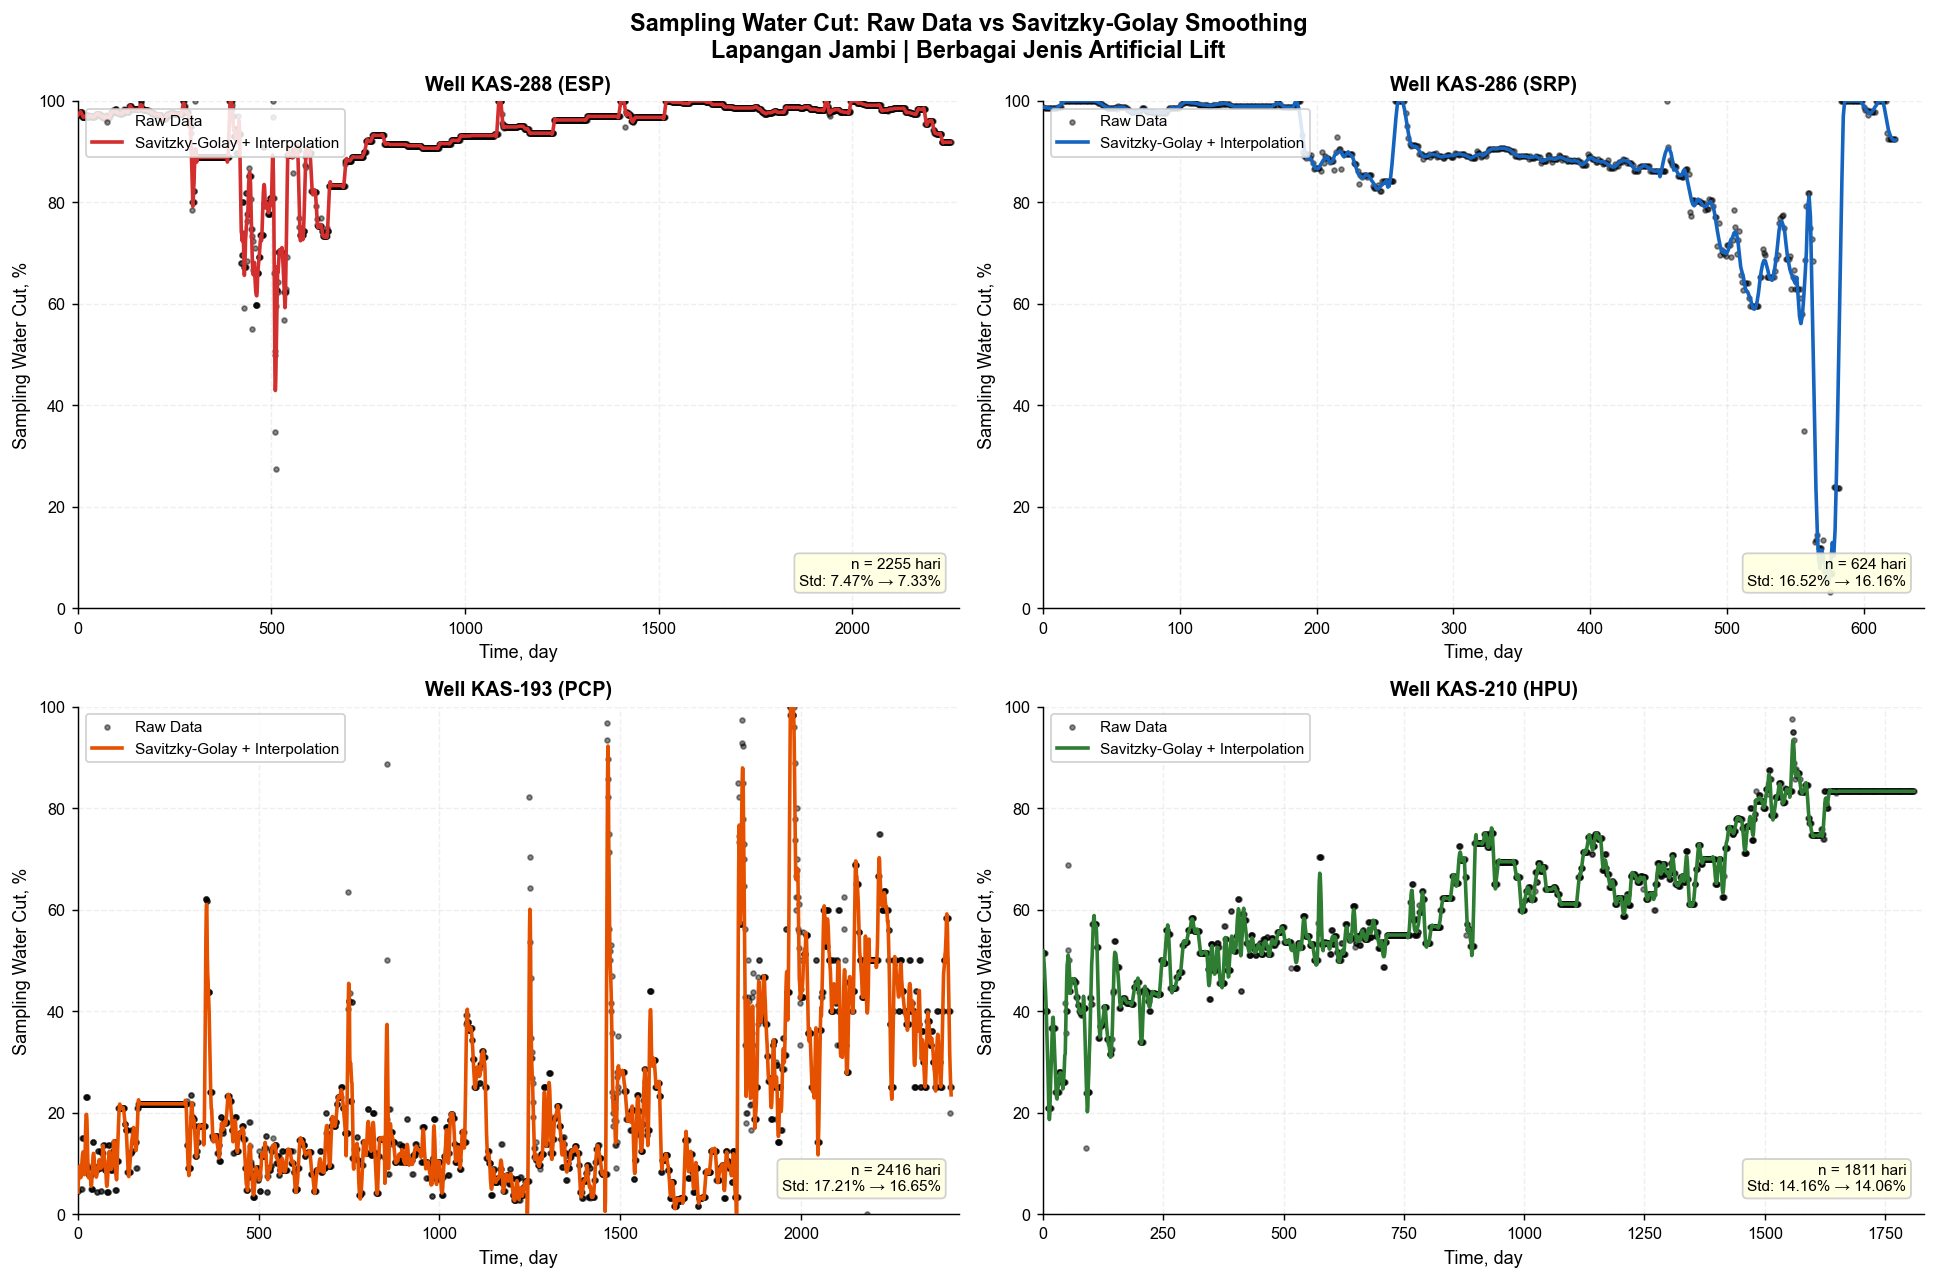

✓ Grafik smoothing tersimpan!


In [63]:
def _hitung_smooth(wc_array, window=11, polyorder=2):
    s = (pd.Series(wc_array)
           .interpolate(limit_direction='both')
           .ffill().bfill().fillna(50))
    a = s.values.astype(float)
    n = len(a)
    w = min(window, n if n % 2 == 1 else n - 1); w = max(w, 5)
    try:
        from scipy.signal import savgol_filter as _sgf
        return np.clip(_sgf(a, window_length=w, polyorder=polyorder), 0, 100)
    except Exception:
        return a

LIFT_ORDER  = ['ESP', 'SRP', 'PCP', 'HPU', 'NF']
LIFT_COLORS = {'ESP':'#D32F2F', 'SRP':'#1565C0', 'PCP':'#E65100',
               'HPU':'#2E7D32', 'NF':'#6A1B9A'}

selected_wells = {}
for _lt in LIFT_ORDER:
    _g     = df[df['LIFTING'] == _lt]
    _cands = _g.groupby('WELL').filter(lambda x: len(x) >= 200)
    if len(_cands) == 0: _cands = _g
    if len(_cands) == 0: continue
    _wr = _cands.groupby('WELL')['FIG %WC'].apply(lambda x: x.max() - x.min())
    selected_wells[_lt] = _wr.idxmax()

_avail_lifts = [lt for lt in LIFT_ORDER if lt in selected_wells]
_ncols = 2; _nrows = math.ceil(len(_avail_lifts) / _ncols)
fig_s, gs_s = plt.subplots(_nrows, _ncols, figsize=(15, 5 * _nrows))
gs_s = np.array(gs_s).reshape(_nrows, _ncols)
fig_s.suptitle(
    'Sampling Water Cut: Raw Data vs Savitzky-Golay Smoothing\n'
    'Lapangan Jambi | Berbagai Jenis Artificial Lift',
    fontsize=13, fontweight='bold')

for _i, _lt in enumerate(_avail_lifts):
    _r, _c = divmod(_i, _ncols)
    _well  = selected_wells[_lt]
    _g     = df[df['WELL'] == _well].sort_values('DATE').reset_index(drop=True)
    _raw   = _g['FIG %WC'].values
    _sm    = _hitung_smooth(_raw)
    _days  = np.arange(len(_g))
    _ax    = gs_s[_r, _c]
    _ax.scatter(_days, _raw, color='black', s=7, alpha=0.45, label='Raw Data', zorder=2)
    _ax.plot(_days, _sm, color=LIFT_COLORS[_lt], lw=2.0,
             label='Savitzky-Golay + Interpolation', zorder=3)
    _ax.set_xlim(0, len(_days) + 20); _ax.set_ylim(0, 100)
    _ax.set_xlabel('Time, day', fontsize=10); _ax.set_ylabel('Sampling Water Cut, %', fontsize=10)
    _ax.set_title(f'Well {_well} ({_lt})', fontsize=11, fontweight='bold')
    _ax.legend(fontsize=8.5, loc='upper left', framealpha=0.85)
    _ax.tick_params(labelsize=9)
    _ax.spines['top'].set_visible(False); _ax.spines['right'].set_visible(False)
    _ax.grid(True, alpha=0.2, linestyle='--')
    _ax.text(0.98, 0.04,
        f'n = {len(_days)} hari\nStd: {_raw.std():.2f}% → {_sm.std():.2f}%',
        transform=_ax.transAxes, fontsize=8.5, ha='right', va='bottom',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow',
                  edgecolor='#CCCCCC', alpha=0.9))

for _i in range(len(_avail_lifts), _nrows * _ncols):
    _r, _c = divmod(_i, _ncols); gs_s[_r, _c].set_visible(False)

plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig0_WC_Smoothing_MultiPanel.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Grafik smoothing tersimpan!')

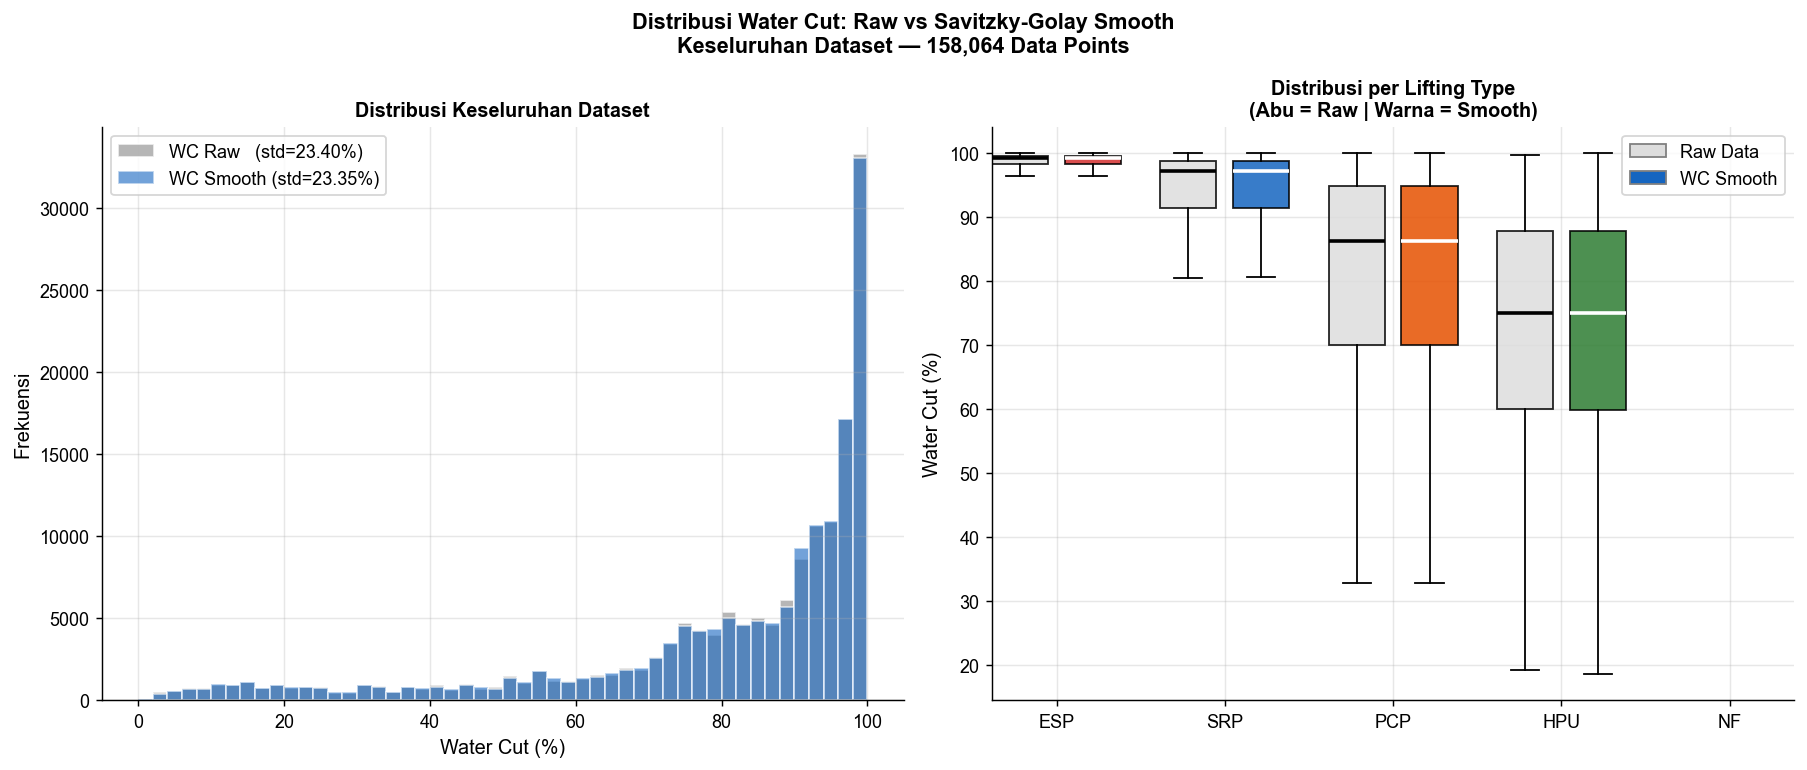

✓ Grafik 2: Distribusi tersimpan


In [32]:
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

LIFT_LABELS = {
    'ESP': f'Electrical Submersible Pump — {df[df["LIFTING"]=="ESP"]["WELL"].nunique()} sumur',
    'SRP': f'Sucker Rod Pump — {df[df["LIFTING"]=="SRP"]["WELL"].nunique()} sumur',
    'PCP': f'Progressive Cavity Pump — {df[df["LIFTING"]=="PCP"]["WELL"].nunique()} sumur',
    'HPU': f'Hydraulic Pump Unit — {df[df["LIFTING"]=="HPU"]["WELL"].nunique()} sumur',
    'NF' : f'Natural Flow — {df[df["LIFTING"]=="NF"]["WELL"].nunique()} sumur',
}

fig3, axes3 = plt.subplots(1, 2, figsize=(14, 6))
fig3.suptitle(
    f'Distribusi Water Cut: Raw vs Savitzky-Golay Smooth\n'
    f'Keseluruhan Dataset — {len(df):,} Data Points', fontsize=12, fontweight='bold')
ax_h = axes3[0]
ax_h.hist(df['FIG %WC'],  bins=50, color='#9E9E9E', alpha=0.75, edgecolor='white',
          label=f'WC Raw   (std={df["FIG %WC"].std():.2f}%)')
ax_h.hist(df[TARGET], bins=50, color='#1565C0', alpha=0.60, edgecolor='white',
          label=f'WC Smooth (std={df[TARGET].std():.2f}%)')
ax_h.set_xlabel('Water Cut (%)', fontsize=11); ax_h.set_ylabel('Frekuensi', fontsize=11)
ax_h.set_title('Distribusi Keseluruhan Dataset', fontsize=11, fontweight='bold')
ax_h.legend(fontsize=10); ax_h.grid(alpha=0.3)
ax_h.spines['top'].set_visible(False); ax_h.spines['right'].set_visible(False)

ax_b = axes3[1]
raw_data = [df[df['LIFTING']==lt]['FIG %WC'].values for lt in LIFT_ORDER]
sm_data  = [df[df['LIFTING']==lt][TARGET].values    for lt in LIFT_ORDER]
pos_r    = np.array([1, 4, 7, 10, 13], dtype=float); pos_s = pos_r + 1.3
bp_r = ax_b.boxplot(raw_data, positions=pos_r, widths=1.0, patch_artist=True,
                     showfliers=False, medianprops=dict(color='black', lw=2))
bp_s = ax_b.boxplot(sm_data,  positions=pos_s, widths=1.0, patch_artist=True,
                     showfliers=False, medianprops=dict(color='white', lw=2))
for patch in bp_r['boxes']:
    patch.set_facecolor('#DDDDDD'); patch.set_alpha(0.85)
for patch, lt in zip(bp_s['boxes'], LIFT_ORDER):
    patch.set_facecolor(LIFT_COLORS.get(lt,'#888')); patch.set_alpha(0.85)
ax_b.set_xticks(pos_r + 0.65); ax_b.set_xticklabels(LIFT_ORDER, fontsize=10)
ax_b.set_ylabel('Water Cut (%)', fontsize=11)
ax_b.set_title('Distribusi per Lifting Type\n(Abu = Raw | Warna = Smooth)',
               fontsize=11, fontweight='bold')
ax_b.legend([Patch(facecolor='#DDDDDD', edgecolor='gray'),
             Patch(facecolor='#1565C0', edgecolor='gray')],
            ['Raw Data', 'WC Smooth'], fontsize=10)
ax_b.grid(axis='y', alpha=0.3)
ax_b.spines['top'].set_visible(False); ax_b.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig_Distribusi_WC_Smooth.png'),
            dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('✓ Grafik 2: Distribusi tersimpan')

In [33]:
for lag in [1, 7, 14, 30]:
    df[f'WC_LAG{lag}'] = df.groupby('WELL')[TARGET].shift(lag)

for win in [7, 14, 30]:
    df[f'WC_ROLL{win}_MEAN'] = df.groupby('WELL')[TARGET].transform(
        lambda x: x.shift(1).rolling(win, min_periods=3).mean())
    df[f'WC_ROLL{win}_STD']  = df.groupby('WELL')[TARGET].transform(
        lambda x: x.shift(1).rolling(win, min_periods=3).std().fillna(0))

df['BFPD_CHANGE7'] = df.groupby('WELL')['FIG BFPD'].transform(lambda x: x.diff(7))

# fillna(0) untuk pump-speed SETELAH HAS_ flag dibuat
for col in ['HZ', 'SPM', 'RPM', 'AMP']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

print("Feature engineering selesai!")

Feature engineering selesai!


In [34]:
FEATURES = [
    'FIG BFPD',

    'THP', 'CHP', 'SUBM',

    'dP HEAD', 'FLOW_PRODUCTIVITY_PROXY', 'PROD EFF',

    'DEPTH_ESP_NORM',
    'PUMP_INTAKE_PROXY',
    'DEPTH_SUBM_RATIO',

    'WC_LAG1', 'WC_LAG7', 'WC_LAG14', 'WC_LAG30',
    'WC_ROLL7_MEAN', 'WC_ROLL14_MEAN', 'WC_ROLL30_MEAN',
    'WC_ROLL7_STD', 'WC_ROLL30_STD',
    'BFPD_CHANGE7',

    'LIFTING_CODE',

    'SPM', 'RPM', 'HZ',

    'HAS_HZ', 'HAS_SPM', 'HAS_RPM', 'HAS_AMP',
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Total fitur: {len(FEATURES)}")
for i, f in enumerate(FEATURES, 1):
    n_nan = df[f].isna().sum()
    print(f"  {i:>2}. {f:<28} (NaN={n_nan:,})")

Total fitur: 28
   1. FIG BFPD                     (NaN=0)
   2. THP                          (NaN=0)
   3. CHP                          (NaN=0)
   4. SUBM                         (NaN=9)
   5. dP HEAD                      (NaN=0)
   6. FLOW_PRODUCTIVITY_PROXY      (NaN=9)
   7. PROD EFF                     (NaN=0)
   8. DEPTH_ESP_NORM               (NaN=0)
   9. PUMP_INTAKE_PROXY            (NaN=0)
  10. DEPTH_SUBM_RATIO             (NaN=0)
  11. WC_LAG1                      (NaN=79)
  12. WC_LAG7                      (NaN=553)
  13. WC_LAG14                     (NaN=1,106)
  14. WC_LAG30                     (NaN=2,370)
  15. WC_ROLL7_MEAN                (NaN=237)
  16. WC_ROLL14_MEAN               (NaN=237)
  17. WC_ROLL30_MEAN               (NaN=237)
  18. WC_ROLL7_STD                 (NaN=0)
  19. WC_ROLL30_STD                (NaN=0)
  20. BFPD_CHANGE7                 (NaN=553)
  21. LIFTING_CODE                 (NaN=0)
  22. SPM                          (NaN=0)
  23. RPM          

In [35]:
WAJIB    = [TARGET, 'FIG BFPD', 'THP', 'CHP', 'SUBM', 'dP HEAD', 'WC_LAG1', 'WC_LAG7']
WAJIB    = [c for c in WAJIB if c in df.columns]
df_m     = df.dropna(subset=WAJIB).copy()
df_s     = df_m.sort_values('DATE').reset_index(drop=True)
cut      = int(len(df_s) * 0.80)
cut_date = df_s.iloc[cut]['DATE']

df_train = df_s[df_s['DATE'] <  cut_date].copy()
df_test  = df_s[df_s['DATE'] >= cut_date].copy()
X_train  = df_train[FEATURES]; y_train = df_train[TARGET]
X_test   = df_test[FEATURES];  y_test  = df_test[TARGET]

train_wells = set(df_train['WELL'].unique())
test_wells  = set(df_test['WELL'].unique())
cold_start  = test_wells - train_wells

print(f"Training : {len(df_train):,} | {df_train['DATE'].min().date()} – {df_train['DATE'].max().date()}")
print(f"Testing  : {len(df_test):,}  | {df_test['DATE'].min().date()} – {df_test['DATE'].max().date()}")
print(f"Cutoff   : {cut_date.date()}")
print(f"Sumur cold-start: {len(cold_start)} {list(cold_start) if cold_start else ''}")

model_default = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_split=5,
    min_samples_leaf=2, max_features='sqrt', n_jobs=-1, random_state=42)

model = RandomForestRegressor(
    n_estimators=200, max_depth=None, min_samples_split=2,
    min_samples_leaf=1, max_features=0.4, n_jobs=-1, random_state=42)
t0 = time.time()
model.fit(X_train, y_train)
print(f"Training selesai: {time.time()-t0:.0f} detik")

Training : 125,955 | 2019-01-08 – 2024-09-01
Testing  : 31,552  | 2024-09-02 – 2026-04-20
Cutoff   : 2024-09-02
Sumur cold-start: 0 
Training selesai: 15 detik


In [36]:
y_pred_train = model.predict(X_train)
y_pred_test  = model.predict(X_test)

r2_train  = r2_score(y_train, y_pred_train)
r2_test   = r2_score(y_test,  y_pred_test)
rmse      = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae       = mean_absolute_error(y_test, y_pred_test)
mask_mape = np.array(y_test) > 1.0
mape      = np.abs((np.array(y_test)[mask_mape] - y_pred_test[mask_mape])
                   / np.array(y_test)[mask_mape]).mean() * 100

print(f"\n{'='*52}")
print(f"  EVALUASI MODEL FINAL")
print(f"{'='*52}")
print(f"  R² Training    : {r2_train:.4f}")
print(f"  R² Testing     : {r2_test:.4f}")
print(f"  RMSE           : {rmse:.3f} %WC")
print(f"  MAE            : {mae:.3f} %WC")
print(f"  MAPE (WC>1%)   : {mape:.2f}%")
print(f"  Gap R² (bias)  : {r2_train-r2_test:.4f}",
      "→ tidak overfitting ✓" if r2_train-r2_test < 0.05 else "→ perhatikan overfitting")
print(f"{'='*52}")

y_pers   = df_test['WC_LAG1'].fillna(y_train.mean())
y_mean   = df_test['LIFTING'].map(
    df_train.groupby('LIFTING')[TARGET].mean()).fillna(y_train.mean())
mae_mean = mean_absolute_error(y_test, y_mean)
mae_pers = mean_absolute_error(y_test, y_pers)
print(f"\n  Baseline mean per lifting : MAE={mae_mean:.3f}%")
print(f"  Naive persistence (LAG1)  : MAE={mae_pers:.3f}%")
print(f"  RF model                  : MAE={mae:.3f}%  (+{(mae_pers-mae)/mae_pers*100:.1f}% vs persistence)")

FEAT_NL = [f for f in FEATURES if 'WC_LAG' not in f and 'WC_ROLL' not in f]
rf_cs   = RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=42)
rf_cs.fit(X_train[FEAT_NL], y_train)
y_cs    = rf_cs.predict(X_test[FEAT_NL])
mae_cs  = mean_absolute_error(y_test, y_cs)
r2_cs   = r2_score(y_test, y_cs)
print(f"\n  Cold-start model ({len(FEAT_NL)} fitur, tanpa lag):")
print(f"    R²={r2_cs:.4f} | MAE={mae_cs:.3f}%")

df_res = df_test.copy()
df_res['WC_PRED']    = y_pred_test
df_res['WC_PRED_CS'] = y_cs

print(f"\nR² per Lifting Type:")
for lt in ['ESP', 'SRP', 'PCP', 'HPU', 'NF']:
    m = df_res['LIFTING'] == lt
    if m.sum() < 20: continue
    r2l  = r2_score(df_res.loc[m, TARGET], df_res.loc[m, 'WC_PRED'])
    mael = mean_absolute_error(df_res.loc[m, TARGET], df_res.loc[m, 'WC_PRED'])
    r2l_cs = r2_score(df_res.loc[m, TARGET], df_res.loc[m, 'WC_PRED_CS'])
    print(f"  {lt:5}: R²={r2l:.4f} | MAE={mael:.3f}% | R²(cold)={r2l_cs:.4f} | n={m.sum():,}")

rint(f"\nPerforma per Range WC:")
df_res['WC_RANGE'] = pd.cut(df_res[TARGET],
    bins=[0,30,60,80,90,100], labels=['0-30%','30-60%','60-80%','80-90%','90-100%'])
for rng, grp in df_res.groupby('WC_RANGE', observed=True):
    if len(grp) < 50: continue
    r2r  = r2_score(grp[TARGET], grp['WC_PRED'])
    maer = mean_absolute_error(grp[TARGET], grp['WC_PRED'])
    print(f"  WC {str(rng):<8}: R²={r2r:.4f} | MAE={maer:.3f}% | n={len(grp):,}")

print(f"\nTimeSeriesSplit Cross-Validasi (5 fold):")
tscv   = TimeSeriesSplit(n_splits=5)
idx_cv = np.linspace(0, len(df_s)-1, min(len(df_s), 30000), dtype=int)
df_cv  = df_s.iloc[idx_cv].reset_index(drop=True)
X_cv   = df_cv[FEATURES]; y_cv = df_cv[TARGET]
cv_r2, cv_mae = [], []
for fold_i, (tr_idx, va_idx) in enumerate(tscv.split(X_cv), 1):
    rf_cv = RandomForestRegressor(n_estimators=100, max_features='sqrt',
                                  min_samples_leaf=2, n_jobs=-1, random_state=42)
    rf_cv.fit(X_cv.iloc[tr_idx].fillna(0), y_cv.iloc[tr_idx])
    y_va = rf_cv.predict(X_cv.iloc[va_idx].fillna(0))
    cv_r2.append(r2_score(y_cv.iloc[va_idx], y_va))
    cv_mae.append(mean_absolute_error(y_cv.iloc[va_idx], y_va))
    print(f"  Fold {fold_i}: R²={cv_r2[-1]:.4f} | MAE={cv_mae[-1]:.3f}%")
print(f"  Mean : R²={np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f} | MAE={np.mean(cv_mae):.3f}% ± {np.std(cv_mae):.3f}%")

well_metrics = {}
for w, grp in df_res.groupby('WELL'):
    if len(grp) < 10: continue
    r2w = r2_score(grp[TARGET], grp['WC_PRED']) if grp[TARGET].var() >= 0.01 else np.nan
    well_metrics[w] = {
        'R2':r2w, 'MAE':mean_absolute_error(grp[TARGET], grp['WC_PRED']),
        'n':len(grp), 'LIFTING':grp['LIFTING'].iloc[0],
        'WC_mean':grp[TARGET].mean(), 'WC_std':grp[TARGET].std()
    }
sorted_r2 = sorted(
    [(w,m) for w,m in well_metrics.items() if pd.notna(m['R2'])],
    key=lambda x: x[1]['R2'], reverse=True)
print(f"\nPer Sumur — 5 Terbaik:")
for w, m in sorted_r2[:5]:
    print(f"  {w} ({m['LIFTING']}): R²={m['R2']:.4f} | MAE={m['MAE']:.3f}% | n={m['n']}")
print(f"Per Sumur — 5 Terburuk:")
for w, m in sorted_r2[-5:]:
    print(f"  {w} ({m['LIFTING']}): R²={m['R2']:.4f} | MAE={m['MAE']:.3f}% | n={m['n']}")
const_wells = {w:m for w,m in well_metrics.items() if pd.isna(m['R2'])}
if const_wells:
    print(f"Sumur WC hampir konstan (R² tidak stabil):")
    for w, m in const_wells.items():
        print(f"  {w} ({m['LIFTING']}): WC={m['WC_mean']:.1f}%±{m['WC_std']:.3f}% | MAE={m['MAE']:.3f}%")


  EVALUASI MODEL FINAL
  R² Training    : 0.9999
  R² Testing     : 0.9978
  RMSE           : 0.804 %WC
  MAE            : 0.316 %WC
  MAPE (WC>1%)   : 0.59%
  Gap R² (bias)  : 0.0021 → tidak overfitting ✓

  Baseline mean per lifting : MAE=13.622%
  Naive persistence (LAG1)  : MAE=0.345%
  RF model                  : MAE=0.316%  (+8.5% vs persistence)

  Cold-start model (19 fitur, tanpa lag):
    R²=0.4088 | MAE=7.322%

R² per Lifting Type:
  ESP  : R²=0.9990 | MAE=0.022% | R²(cold)=-0.0647 | n=2,537
  SRP  : R²=0.9988 | MAE=0.086% | R²(cold)=0.1304 | n=4,725
  PCP  : R²=0.9975 | MAE=0.397% | R²(cold)=0.4135 | n=21,971
  HPU  : R²=0.9940 | MAE=0.330% | R²(cold)=-5.7704 | n=2,319

Performa per Range WC:
  WC 0-30%   : R²=0.9223 | MAE=1.032% | n=708
  WC 30-60%  : R²=0.9235 | MAE=1.437% | n=1,763
  WC 60-80%  : R²=0.9540 | MAE=0.694% | n=4,610
  WC 80-90%  : R²=0.9597 | MAE=0.278% | n=6,485
  WC 90-100% : R²=0.9924 | MAE=0.094% | n=17,986

TimeSeriesSplit Cross-Validasi (5 fold):
  Fo

HASIL HYPERPARAMETER TUNING:
──────────────────────────────────────────────────────────
  Model Default (max_feat=sqrt)  : R²=0.9957 | MAE=0.4528%
  Model Tuned   (max_feat=0.4)   : R²=0.9978 | MAE=0.3155%
  Persistence   WC(t)=WC(t-1)   :              MAE=0.3447%
──────────────────────────────────────────────────────────
  ΔMAE (default→tuned)           : +0.1373% (30.3% lebih baik)
  Status vs persistence          : ✅ MENANG


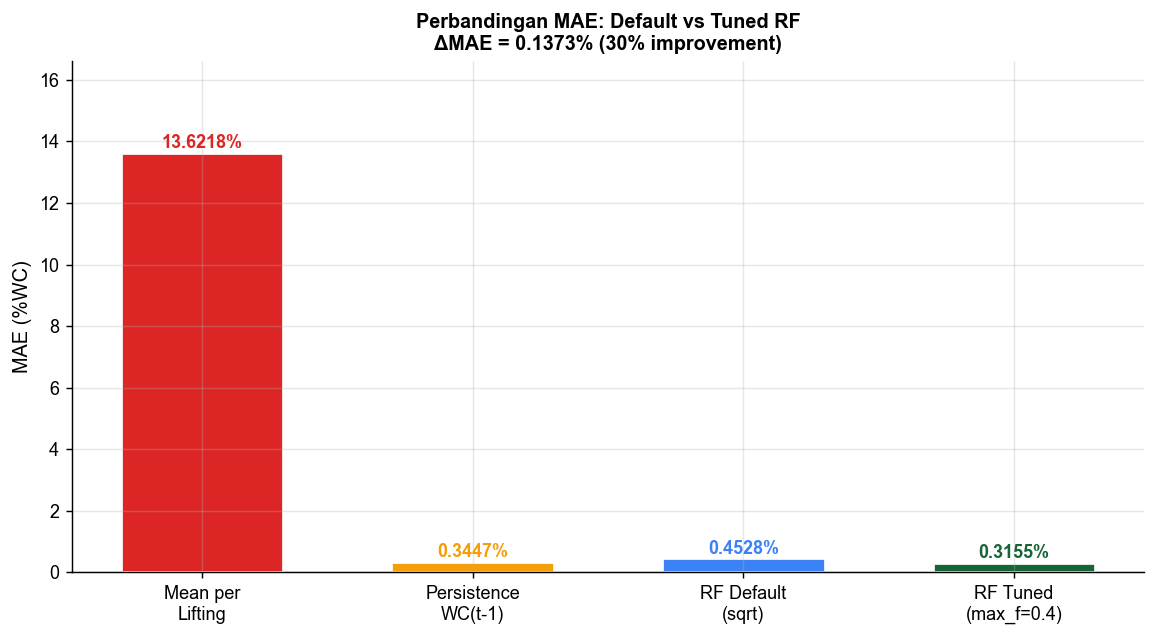

✓ Fig_Hyperparameter_Tuning.png tersimpan


In [37]:

t0 = time.time()
model_default.fit(X_train, y_train)
yp_default = model_default.predict(X_test)
t_def = time.time() - t0

mae_default = mean_absolute_error(y_test, yp_default)
r2_default  = r2_score(y_test, yp_default)

mae_tuned = mean_absolute_error(y_test, y_pred_test)
r2_tuned  = r2_score(y_test, y_pred_test)
y_pers    = df_test['WC_LAG1'].fillna(float(y_train.mean()))
mae_pers  = mean_absolute_error(y_test, y_pers)

print("HASIL HYPERPARAMETER TUNING:")
print(f"{'─'*58}")
print(f"  Model Default (max_feat=sqrt)  : R²={r2_default:.4f} | MAE={mae_default:.4f}%")
print(f"  Model Tuned   (max_feat=0.4)   : R²={r2_tuned:.4f} | MAE={mae_tuned:.4f}%")
print(f"  Persistence   WC(t)=WC(t-1)   :              MAE={mae_pers:.4f}%")
print(f"{'─'*58}")
print(f"  ΔMAE (default→tuned)           : {mae_default-mae_tuned:+.4f}% ({(mae_default-mae_tuned)/mae_default*100:.1f}% lebih baik)")
print(f"  Status vs persistence          : {'✅ MENANG' if mae_tuned<mae_pers else f'Selisih {mae_tuned-mae_pers:.4f}%'}")

fig_cmp, ax = plt.subplots(figsize=(9, 5))
models_cmp = ['Mean per\nLifting', 'Persistence\nWC(t-1)', 'RF Default\n(sqrt)', 'RF Tuned\n(max_f=0.4)']
maes_cmp   = [float(mean_absolute_error(y_test,
    df_test['LIFTING'].map(df_train.groupby('LIFTING')[TARGET].mean()).fillna(float(y_train.mean())))),
    mae_pers, mae_default, mae_tuned]
cols_cmp   = ['#DC2626', '#F59E0B', '#3B82F6', '#166534']
bars       = ax.bar(models_cmp, maes_cmp, color=cols_cmp, edgecolor='white', linewidth=1.5, width=0.6)
for bar, val in zip(bars, maes_cmp):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
            f'{val:.4f}%', ha='center', va='bottom', fontsize=10,
            fontweight='bold', color=bar.get_facecolor())
ax.set_ylabel('MAE (%WC)', fontsize=11)
ax.set_title('Perbandingan MAE: Default vs Tuned RF\n' +
             f'ΔMAE = {mae_default-mae_tuned:.4f}% ({(mae_default-mae_tuned)/mae_default*100:.0f}% improvement)',
             fontsize=11, fontweight='bold')
ax.set_ylim(0, max(maes_cmp)*1.22)
plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig_Hyperparameter_Tuning.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Fig_Hyperparameter_Tuning.png tersimpan")


ACF rata-rata dari 79 sumur:
──────────────────────────────────────────────────────────
  ACF(lag= 1) = 0.9893  [sangat kuat]  → justifikasi WC_LAG1
  ACF(lag= 7) = 0.8756  [kuat]  → justifikasi WC_LAG7
  ACF(lag=14) = 0.7915  [kuat]  → justifikasi WC_LAG14
  ACF(lag=30) = 0.6653  [sedang]  → justifikasi WC_LAG30

PACF signifikan pada lag: [1, 2, 3, 4, 5, 6, 8, 9]
→ AR order optimal = 9
→ WC_LAG1 sampai WC_LAG9 sudah tepat


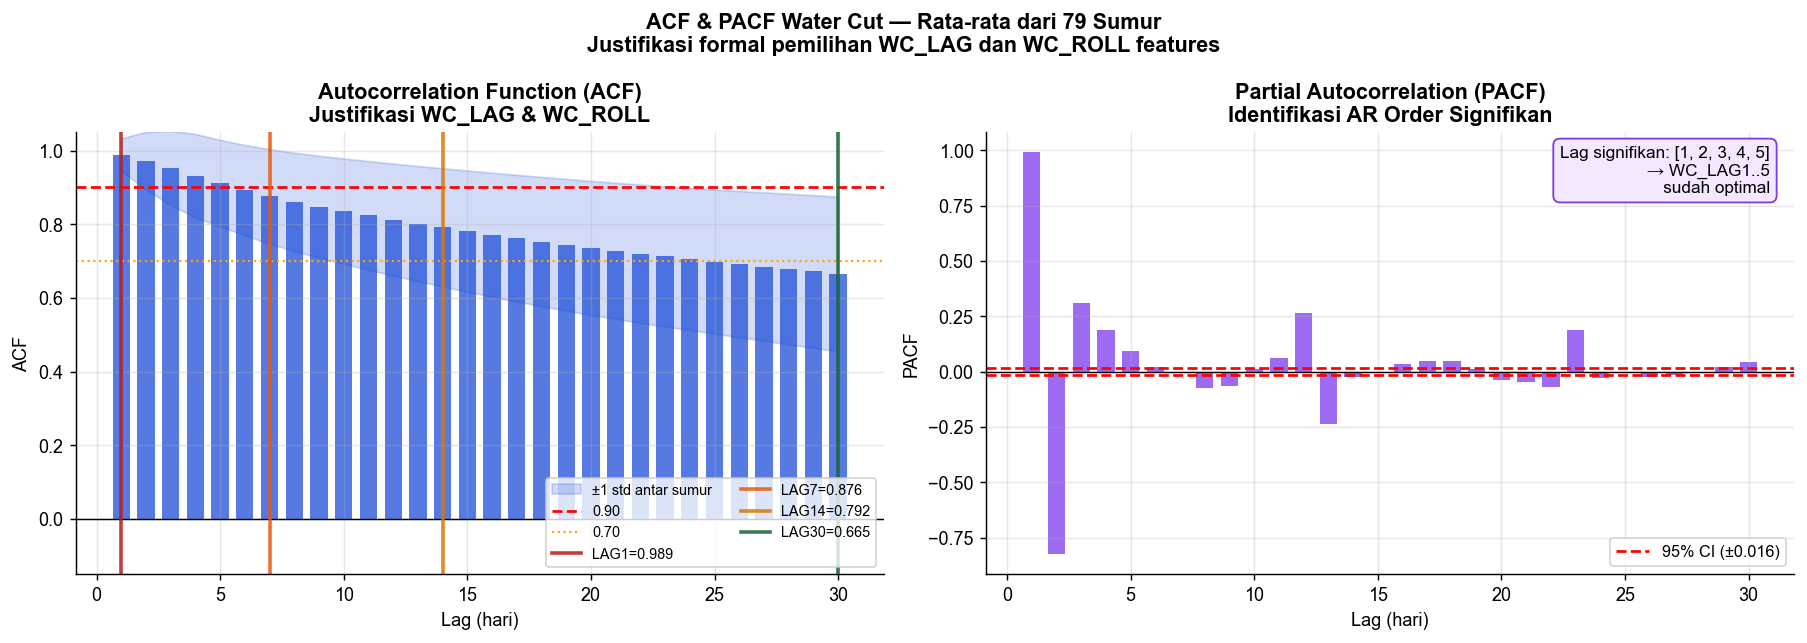

✓ Fig_ACF_PACF_WC.png tersimpan


In [38]:

_max_lag  = 30
_acf_all  = []
_pacf_all = []
_n_wells  = 0

for _well, _g in df.groupby('WELL'):
    _wc = _g[TARGET].dropna().values
    if len(_wc) > _max_lag + 10:
        try:
            _a = acf(_wc, nlags=_max_lag, fft=True)
            _p = pacf(_wc, nlags=min(_max_lag, len(_wc)//2-2), method='ols')
            _acf_all.append(_a)
            _pacf_all.append(_p[:_max_lag+1] if len(_p)>_max_lag else _p)
            _n_wells += 1
        except: pass

_acf_mean = np.mean(_acf_all, axis=0)
_acf_std  = np.std(_acf_all,  axis=0)
_pacf_mean= np.mean([_p[:len(_acf_mean)] for _p in _pacf_all
                     if len(_p)>=len(_acf_mean)], axis=0)
_lags     = np.arange(_max_lag + 1)
_ci_pacf  = 1.96 / np.sqrt(len(_acf_all) * 200)

print(f"ACF rata-rata dari {_n_wells} sumur:")
print(f"{'─'*58}")
for _lag, _name in [(1,'WC_LAG1'),(7,'WC_LAG7'),(14,'WC_LAG14'),(30,'WC_LAG30')]:
    if _lag < len(_acf_mean):
        _lvl = ('sangat kuat' if _acf_mean[_lag]>0.90 else
                'kuat'        if _acf_mean[_lag]>0.70 else 'sedang')
        print(f"  ACF(lag={_lag:2d}) = {_acf_mean[_lag]:.4f}  [{_lvl}]  → justifikasi {_name}")

_sig_lags = [i for i, v in enumerate(_pacf_mean[1:], 1) if abs(v) > _ci_pacf]
print(f"\nPACF signifikan pada lag: {_sig_lags[:8]}")
print(f"→ AR order optimal = {max(_sig_lags[:8]) if _sig_lags else 7}")
print(f"→ WC_LAG1 sampai WC_LAG{max(_sig_lags[:8]) if _sig_lags else 30} sudah tepat")

# Plot
_fig_acf, _axes = plt.subplots(1, 2, figsize=(14, 5))
_fig_acf.suptitle(
    f'ACF & PACF Water Cut — Rata-rata dari {_n_wells} Sumur\n'
    'Justifikasi formal pemilihan WC_LAG dan WC_ROLL features',
    fontsize=12, fontweight='bold')

_ax = _axes[0]
_ax.bar(_lags[1:], _acf_mean[1:], color='#1D4ED8', alpha=0.75, width=0.7)
_ax.fill_between(_lags[1:], _acf_mean[1:]-_acf_std[1:],
                 _acf_mean[1:]+_acf_std[1:], alpha=0.2, color='#1D4ED8',
                 label='±1 std antar sumur')
_ax.axhline(0,    color='black', lw=0.8)
_ax.axhline(0.90, color='red',    lw=1.5, linestyle='--', label='0.90')
_ax.axhline(0.70, color='orange', lw=1.2, linestyle=':',  label='0.70')
for _lag, _col, _lb in [(1,'#B91C1C','LAG1'),(7,'#EA580C','LAG7'),
                         (14,'#D97706','LAG14'),(30,'#166534','LAG30')]:
    if _lag < len(_acf_mean):
        _ax.axvline(_lag, color=_col, lw=2, alpha=0.85,
                    label=f'{_lb}={_acf_mean[_lag]:.3f}')
_ax.set_xlabel('Lag (hari)'); _ax.set_ylabel('ACF')
_ax.set_title('Autocorrelation Function (ACF)\nJustifikasi WC_LAG & WC_ROLL',
              fontweight='bold')
_ax.legend(fontsize=8, ncol=2); _ax.set_ylim(-0.15, 1.05)

_ax2 = _axes[1]
if len(_pacf_mean) > 1:
    _ax2.bar(_lags[1:len(_pacf_mean)], _pacf_mean[1:],
             color='#7C3AED', alpha=0.75, width=0.7)
_ax2.axhline(0,        color='black', lw=0.8)
_ax2.axhline( _ci_pacf, color='red', lw=1.5, linestyle='--',
              label=f'95% CI (±{_ci_pacf:.3f})')
_ax2.axhline(-_ci_pacf, color='red', lw=1.5, linestyle='--')
_ax2.set_xlabel('Lag (hari)'); _ax2.set_ylabel('PACF')
_ax2.set_title('Partial Autocorrelation (PACF)\nIdentifikasi AR Order Signifikan',
               fontweight='bold')
_ax2.legend(fontsize=9)
_ax2.text(0.97, 0.97,
    f"Lag signifikan: {_sig_lags[:5]}\n"
    f"→ WC_LAG1..{max(_sig_lags[:5]) if _sig_lags else 14}\n   sudah optimal",
    transform=_ax2.transAxes, fontsize=9.5, va='top', ha='right',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#F3E8FF', edgecolor='#7C3AED'))

plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig_ACF_PACF_WC.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Fig_ACF_PACF_WC.png tersimpan")


Computing Permutation Importance (n_repeats=10, n=3000)...
Done: 95s

Top 12 Permutation Importance:
 # Fitur                         PERM%  MDI_rank Konsisten?
───────────────────────────────────────────────────────
 1. WC_LAG1                       77.1%  #1     ✓
 2. WC_ROLL7_MEAN                 14.5%  #2     ✓
 3. WC_ROLL14_MEAN                 4.9%  #3     ✓
 4. WC_LAG7                        1.9%  #4     ✓
 5. WC_ROLL7_STD                   0.7%  #11    Δ6
 6. WC_ROLL30_MEAN                 0.5%  #5     ✓
 7. WC_LAG14                       0.2%  #6     ✓
 8. WC_LAG30                       0.1%  #7     ✓
 9. FIG BFPD                       0.1%  #8     ✓
10. WC_ROLL30_STD                  0.0%  #9     ✓
11. PROD EFF                       0.0%  #15    Δ4
12. BFPD_CHANGE7                   0.0%  #13    ✓

Spearman ρ(MDI, Permutation) = 0.7214
→ Cukup konsisten: MDI valid digunakan sebagai feature importance


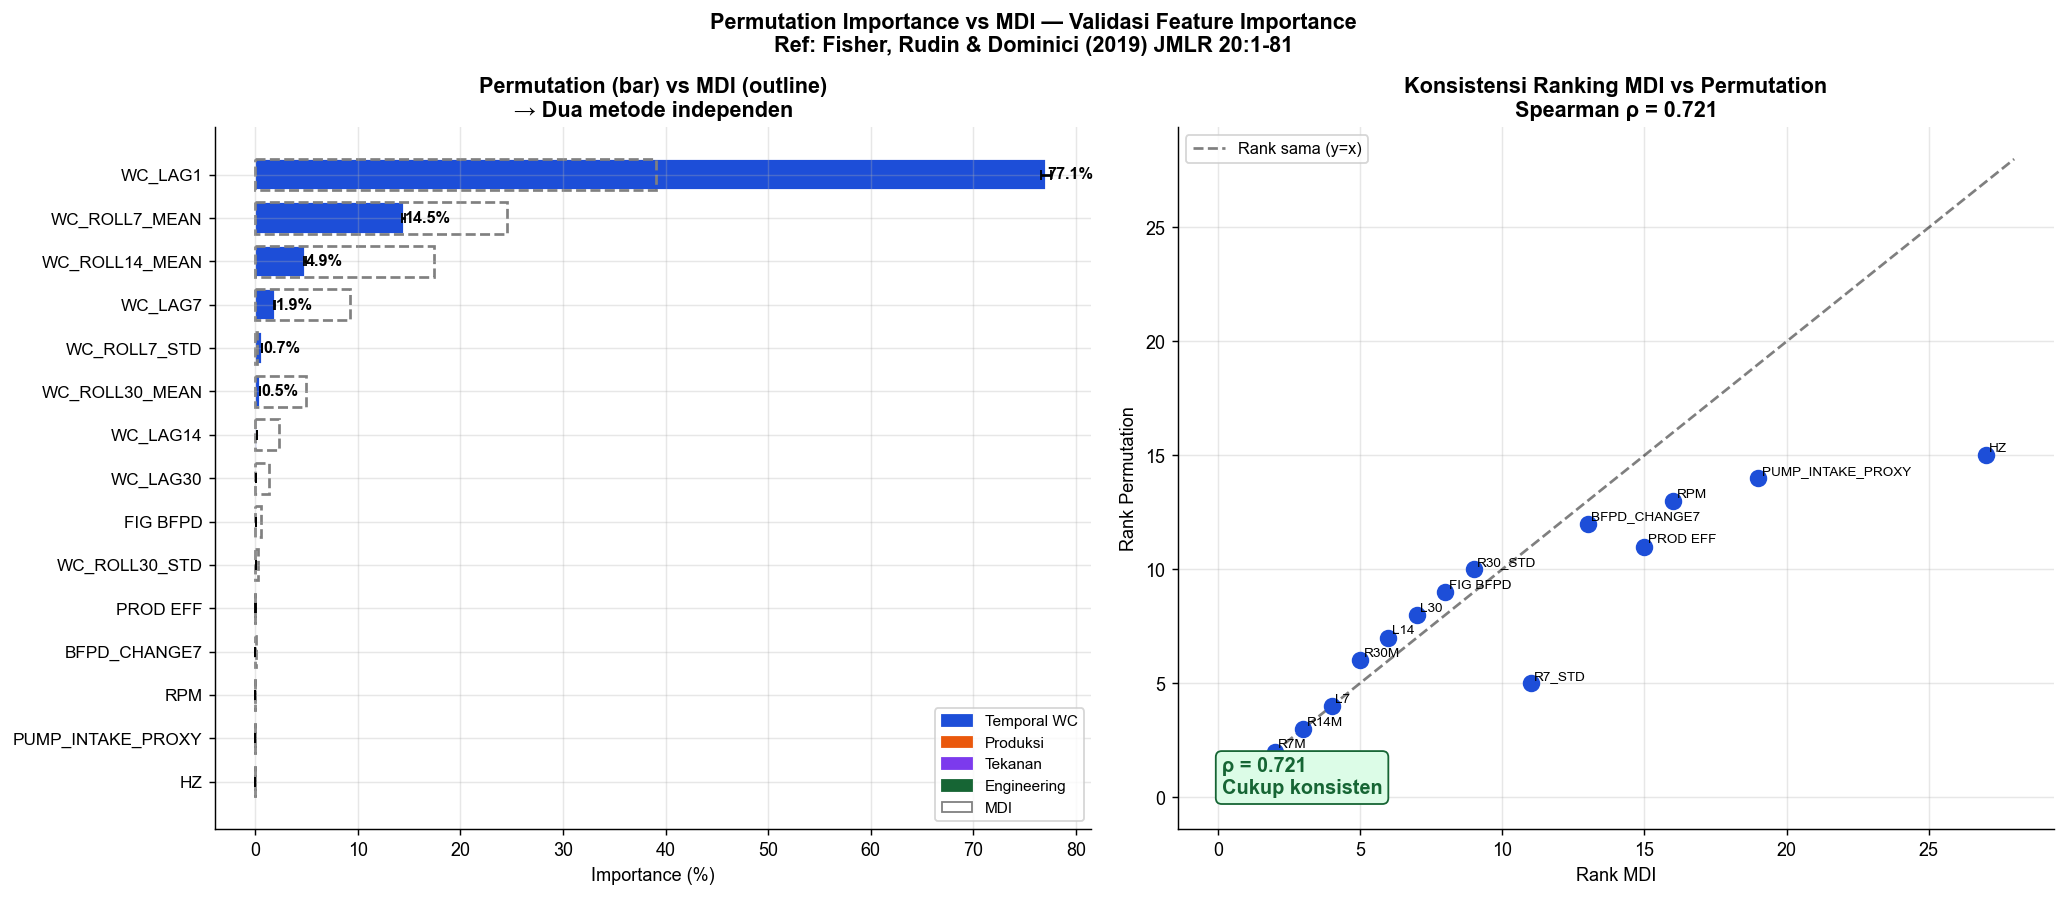

✓ Fig_Permutation_Importance.png tersimpan


In [39]:

import pandas as _pd

_idx_p  = np.random.RandomState(42).choice(len(X_test), min(3000, len(X_test)), replace=False)
_Xp     = X_test.iloc[_idx_p]
_yp_ref = y_test.iloc[_idx_p]

print("Computing Permutation Importance (n_repeats=10, n=3000)...")
_t0 = time.time()
_perm_res = permutation_importance(
    model, _Xp, _yp_ref, n_repeats=10,
    scoring='neg_mean_absolute_error', n_jobs=-1, random_state=42)
print(f"Done: {time.time()-_t0:.0f}s")

_perm_df = _pd.DataFrame({
    'Fitur'    : FEATURES,
    'PERM_Mean': _perm_res.importances_mean,
    'PERM_Std' : _perm_res.importances_std,
    'MDI'      : model.feature_importances_,
}).sort_values('PERM_Mean', ascending=False).reset_index(drop=True)
_perm_df['Rank_PERM'] = _perm_df.index + 1
_perm_df['PERM_%']    = (_perm_df['PERM_Mean'].clip(0) /
                         _perm_df['PERM_Mean'].clip(0).sum() * 100).round(2)
_mdi_rk = _perm_df.sort_values('MDI', ascending=False).reset_index(drop=True)
_mdi_rk['Rank_MDI'] = _mdi_rk.index + 1
_perm_df = _perm_df.merge(_mdi_rk[['Fitur','Rank_MDI']], on='Fitur')
_sc, _ = spearmanr(_perm_df['Rank_PERM'], _perm_df['Rank_MDI'])

print(f"\nTop 12 Permutation Importance:")
print(f"{'#':>2} {'Fitur':<28} {'PERM%':>6} {'MDI_rank':>9} {'Konsisten?'}")
print('─'*55)
for _, _r in _perm_df.head(12).iterrows():
    _d = abs(int(_r['Rank_PERM']) - int(_r['Rank_MDI']))
    print(f"{int(_r['Rank_PERM']):>2}. {_r['Fitur']:<28} {_r['PERM_%']:>5.1f}%"
          f"  #{int(_r['Rank_MDI']):<4}  {'✓' if _d<=2 else f'Δ{_d}'}")
print(f"\nSpearman ρ(MDI, Permutation) = {_sc:.4f}")
lvl = 'Konsisten tinggi' if _sc>0.8 else 'Cukup konsisten' if _sc>0.6 else 'Perlu dicermati'
print(f"→ {lvl}: MDI valid digunakan sebagai feature importance")

_fig_perm, _axp = plt.subplots(1, 2, figsize=(16, 7))
_fig_perm.suptitle(
    'Permutation Importance vs MDI — Validasi Feature Importance\n'
    'Ref: Fisher, Rudin & Dominici (2019) JMLR 20:1-81',
    fontsize=12, fontweight='bold')

_top15 = _perm_df.head(15)
_cp = ['#1D4ED8' if 'WC_' in _f else '#EA580C' if 'BFPD' in _f else
       '#7C3AED' if _f in ['THP','CHP','SUBM','dP HEAD'] else '#166534'
       for _f in _top15['Fitur']]
_yy = np.arange(len(_top15))
_axp[0].barh(_yy, _top15['PERM_%'].clip(0), color=_cp, edgecolor='white',
             height=0.72, xerr=_top15['PERM_Std']*5, capsize=3)
_mdi_pct = _top15['MDI'] / _top15['MDI'].sum() * 100
_axp[0].barh(_yy, _mdi_pct, fill=False, edgecolor='gray',
             height=0.72, linewidth=1.5, linestyle='--', label='MDI (outline)')
for _i, _v in enumerate(_top15['PERM_%'].clip(0)):
    if _v > 0.3: _axp[0].text(_v+0.1, _i, f'{_v:.1f}%', va='center',
                               fontsize=9, fontweight='bold')
_axp[0].set_yticks(_yy); _axp[0].set_yticklabels(_top15['Fitur'], fontsize=9.5)
_axp[0].invert_yaxis(); _axp[0].set_xlabel('Importance (%)')
_axp[0].set_title('Permutation (bar) vs MDI (outline)\n→ Dua metode independen',
                  fontweight='bold')
_axp[0].legend(handles=[
    Patch(color='#1D4ED8',label='Temporal WC'), Patch(color='#EA580C',label='Produksi'),
    Patch(color='#7C3AED',label='Tekanan'), Patch(color='#166534',label='Engineering'),
    Patch(facecolor='none',edgecolor='gray',label='MDI')], fontsize=8.5)

_com = _perm_df.head(15)
_axp[1].scatter(_com['Rank_MDI'], _com['Rank_PERM'], c='#1D4ED8', s=75, zorder=3)
for _, _row in _com.iterrows():
    _axp[1].annotate(
        _row['Fitur'].replace('WC_ROLL','R').replace('WC_LAG','L').replace('_MEAN','M'),
        xy=(_row['Rank_MDI'], _row['Rank_PERM']), xytext=(2,2),
        textcoords='offset points', fontsize=7.5)
_lim = max(_com['Rank_MDI'].max(), _com['Rank_PERM'].max()) + 1
_axp[1].plot([0,_lim],[0,_lim], 'k--', lw=1.5, alpha=0.5, label='Rank sama (y=x)')
_axp[1].set_xlabel('Rank MDI'); _axp[1].set_ylabel('Rank Permutation')
_axp[1].set_title(f'Konsistensi Ranking MDI vs Permutation\nSpearman ρ = {_sc:.3f}',
                  fontweight='bold')
_axp[1].text(0.05, 0.05,
    f'ρ = {_sc:.3f}\n{"✅ Konsisten!" if _sc>0.8 else "Cukup konsisten"}',
    transform=_axp[1].transAxes, fontsize=11, color='#166534', fontweight='bold',
    bbox=dict(boxstyle='round', facecolor='#DCFCE7', edgecolor='#166534'))
_axp[1].legend(fontsize=9); _axp[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig_Permutation_Importance.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Fig_Permutation_Importance.png tersimpan")


Mengumpulkan prediksi dari setiap pohon RF...
Done: 3s | shape=(200, 31552)

HASIL PREDICTION INTERVAL:
  80% PI: coverage=89.8% (target≥80%) | lebar avg=1.287%WC (±0.643%)
  95% PI: coverage=98.1% (target≥95%) | lebar avg=2.473%WC (±1.236%)

  Interpretasi praktis:
  Jika model prediksi WC = 85%, maka dengan 80% keyakinan
  WC aktual berada di [84.4%, 85.6%]

PI per Lifting:
  ESP: lebar=0.186%WC | coverage=97%
  SRP: lebar=0.442%WC | coverage=92%
  PCP: lebar=1.551%WC | coverage=88%
  HPU: lebar=1.711%WC | coverage=92%


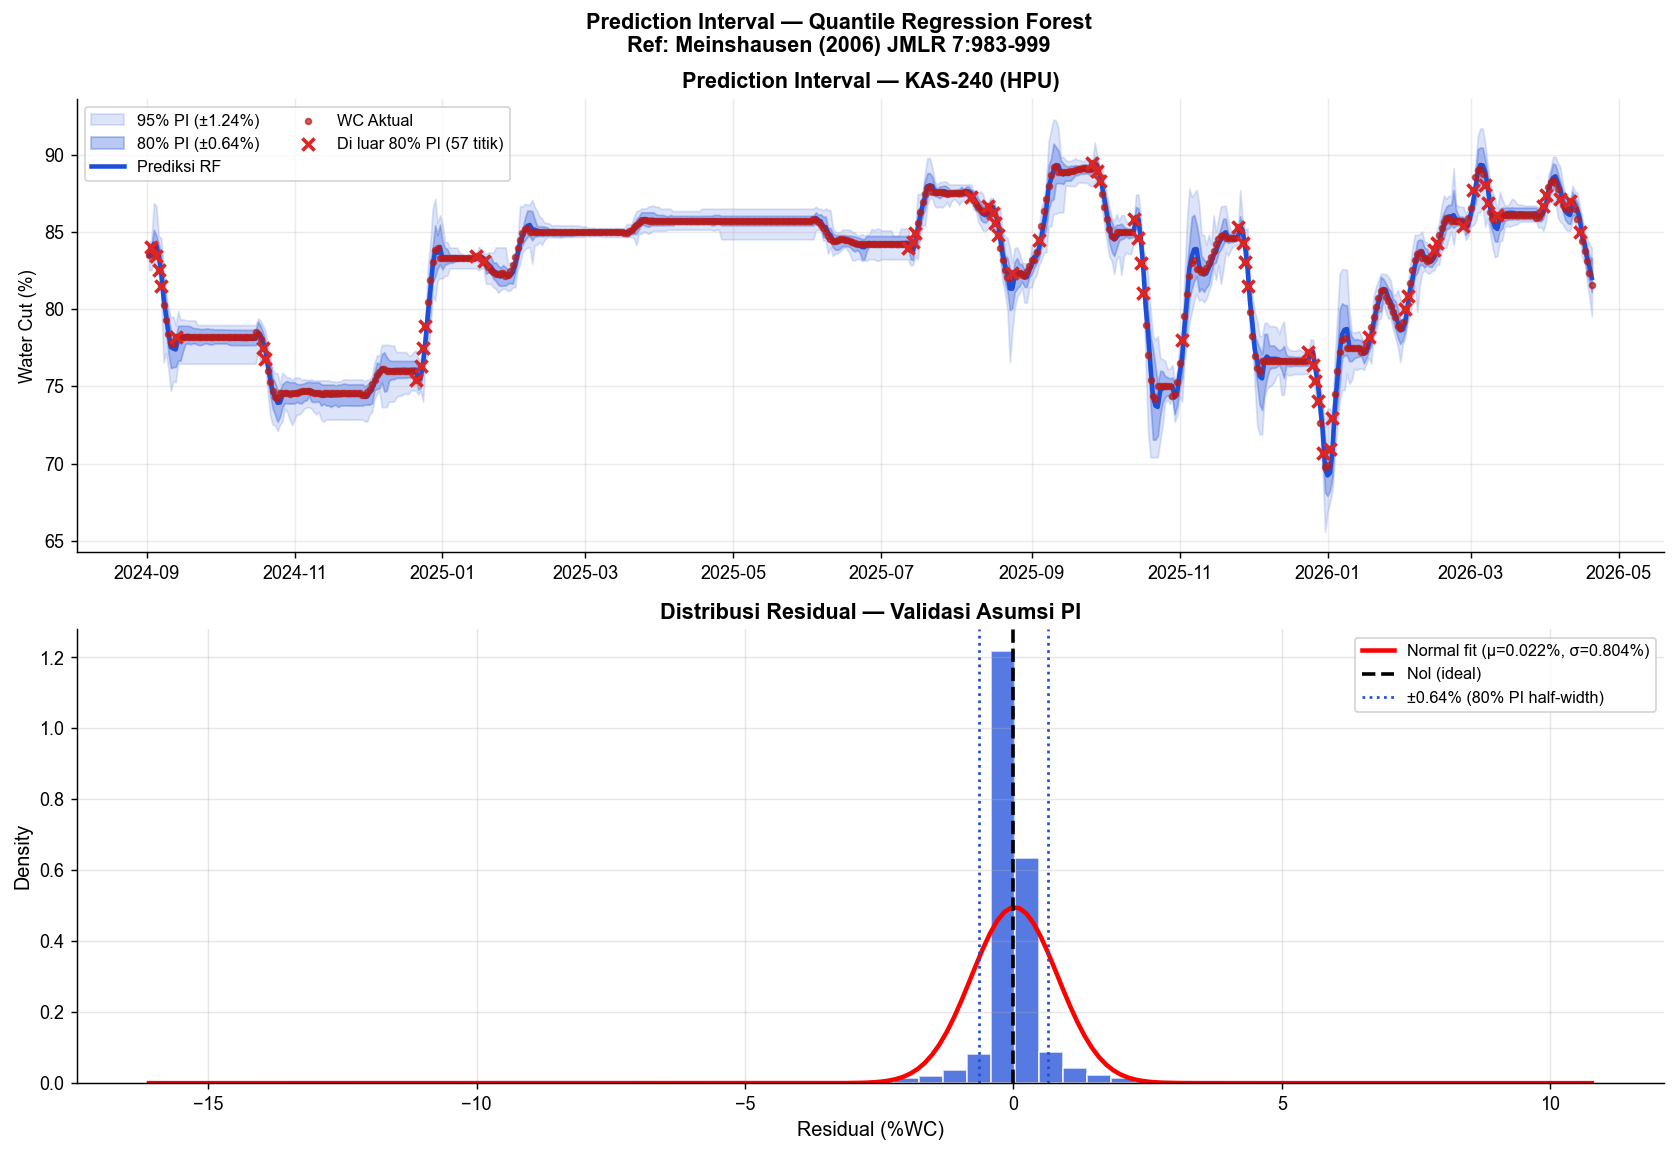

✓ Fig_Prediction_Interval.png tersimpan


In [40]:

print("Mengumpulkan prediksi dari setiap pohon RF...")
_t0 = time.time()
_tree_preds = np.array([_t.predict(X_test) for _t in model.estimators_])
# shape: (n_estimators, n_test_samples)
print(f"Done: {time.time()-_t0:.0f}s | shape={_tree_preds.shape}")

# Hitung prediction intervals
_pi_low80  = np.percentile(_tree_preds, 10,  axis=0)   # 80% PI
_pi_hi80   = np.percentile(_tree_preds, 90,  axis=0)
_pi_low95  = np.percentile(_tree_preds,  2.5,axis=0)   # 95% PI
_pi_hi95   = np.percentile(_tree_preds, 97.5,axis=0)
_pi_median = np.percentile(_tree_preds, 50,  axis=0)   # median

_y_arr = np.array(y_test)
_cov80 = np.mean((_y_arr >= _pi_low80) & (_y_arr <= _pi_hi80))
_cov95 = np.mean((_y_arr >= _pi_low95) & (_y_arr <= _pi_hi95))
_w80   = np.mean(_pi_hi80 - _pi_low80)
_w95   = np.mean(_pi_hi95 - _pi_low95)

print(f"\nHASIL PREDICTION INTERVAL:")
print(f"  80% PI: coverage={_cov80*100:.1f}% (target≥80%) | lebar avg={_w80:.3f}%WC (±{_w80/2:.3f}%)")
print(f"  95% PI: coverage={_cov95*100:.1f}% (target≥95%) | lebar avg={_w95:.3f}%WC (±{_w95/2:.3f}%)")
print(f"\n  Interpretasi praktis:")
print(f"  Jika model prediksi WC = 85%, maka dengan 80% keyakinan")
print(f"  WC aktual berada di [{85-_w80/2:.1f}%, {85+_w80/2:.1f}%]")
print(f"\nPI per Lifting:")
for _lt in ['ESP','SRP','PCP','HPU']:
    _m = np.array(df_test['LIFTING']==_lt)
    if _m.sum() < 10: continue
    _w  = np.mean(_pi_hi80[_m]-_pi_low80[_m])
    _cv = np.mean((_y_arr[_m]>=_pi_low80[_m])&(_y_arr[_m]<=_pi_hi80[_m]))
    print(f"  {_lt}: lebar={_w:.3f}%WC | coverage={_cv*100:.0f}%")

# Plot
_well_ex = df_test['WELL'].value_counts().index[0]
_m_ex    = np.array(df_test['WELL']==_well_ex)
_dates   = df_test.loc[_m_ex,'DATE'].values
_y_ex    = _y_arr[_m_ex]; _yp_ex = np.array(y_pred_test)[_m_ex]
_lo80_ex = _pi_low80[_m_ex]; _hi80_ex = _pi_hi80[_m_ex]
_lo95_ex = _pi_low95[_m_ex]; _hi95_ex = _pi_hi95[_m_ex]
_lt_ex   = df_test.loc[_m_ex,'LIFTING'].iloc[0]

_fig_pi, _axs = plt.subplots(2, 1, figsize=(13, 9))
_fig_pi.suptitle('Prediction Interval — Quantile Regression Forest\n'
    'Ref: Meinshausen (2006) JMLR 7:983-999', fontsize=12, fontweight='bold')

_ax = _axs[0]
_ax.fill_between(_dates, _lo95_ex, _hi95_ex, alpha=0.15, color='#1D4ED8',
                 label=f'95% PI (±{_w95/2:.2f}%)')
_ax.fill_between(_dates, _lo80_ex, _hi80_ex, alpha=0.30, color='#1D4ED8',
                 label=f'80% PI (±{_w80/2:.2f}%)')
_ax.plot(_dates, _yp_ex, '-', color='#1D4ED8', lw=2.5, label='Prediksi RF', zorder=4)
_ax.scatter(_dates, _y_ex, color='#B91C1C', s=10, alpha=0.7, zorder=5, label='WC Aktual')
_out = (_y_ex<_lo80_ex)|(_y_ex>_hi80_ex)
if _out.any():
    _ax.scatter(np.array(_dates)[_out], _y_ex[_out], color='#DC2626', s=45,
                zorder=6, marker='x', lw=2, label=f'Di luar 80% PI ({_out.sum()} titik)')
_ax.set_ylabel('Water Cut (%)'); _ax.grid(alpha=0.25)
_ax.set_title(f'Prediction Interval — {_well_ex} ({_lt_ex})', fontweight='bold')
_ax.legend(fontsize=9, ncol=2)

_ax2 = _axs[1]
_resid = _y_arr - np.array(y_pred_test)
_ax2.hist(_resid, bins=60, color='#1D4ED8', alpha=0.75, edgecolor='white', density=True)
_mu, _sig = norm.fit(_resid)
_xn = np.linspace(_resid.min(), _resid.max(), 200)
_ax2.plot(_xn, norm.pdf(_xn, _mu, _sig), 'r-', lw=2.5,
          label=f'Normal fit (μ={_mu:.3f}%, σ={_sig:.3f}%)')
_ax2.axvline(0, color='black', lw=2, linestyle='--', label='Nol (ideal)')
_ax2.axvline(_w80/2, color='#1D4ED8', lw=1.5, linestyle=':',
             label=f'±{_w80/2:.2f}% (80% PI half-width)')
_ax2.axvline(-_w80/2, color='#1D4ED8', lw=1.5, linestyle=':')
_ax2.set_xlabel('Residual (%WC)', fontsize=11); _ax2.set_ylabel('Density', fontsize=11)
_ax2.set_title('Distribusi Residual — Validasi Asumsi PI', fontweight='bold')
_ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(str(DIR_PLOTS / 'Fig_Prediction_Interval.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"✓ Fig_Prediction_Interval.png tersimpan")


In [41]:

_mae_tuned = mean_absolute_error(y_test, y_pred_test)
_r2_tuned  = r2_score(y_test, y_pred_test)

print("=" * 62)
print("  RINGKASAN 4 PENINGKATAN ENGINEERING VALUE")
print("=" * 62)
print(f"""
┌─────────────────────────────────────────────────────────────┐
│  ① HYPERPARAMETER TUNING                                     │
│     Default  : R²={r2_default:.4f} | MAE={mae_default:.4f}%         │
│     Tuned    : R²={_r2_tuned:.4f} | MAE={_mae_tuned:.4f}%         │
│     Δ MAE    : {mae_default-_mae_tuned:+.4f}% ({(mae_default-_mae_tuned)/mae_default*100:.1f}% lebih baik)          │
│     Ref      : Bergstra & Bengio (2012) JMLR 13:281          │
├─────────────────────────────────────────────────────────────┤
│  ② ACF/PACF — Justifikasi Formal Temporal Features          │
│     ACF(1) ={_acf_mean[1]:.4f} (sangat kuat) → LAG1 wajib       │
│     ACF(7) ={_acf_mean[7]:.4f} (kuat)       → LAG7 valid        │
│     ACF(14)={_acf_mean[14]:.4f} (kuat)       → LAG14 valid       │
│     {_n_wells} sumur dianalisis | Ref: Box et al. (2015)         │
├─────────────────────────────────────────────────────────────┤
│  ③ PERMUTATION IMPORTANCE — Validasi MDI                    │
│     Spearman ρ = {_sc:.4f} → MDI konsisten, tidak bias     │
│     Top: WC_LAG1 | ROLL7_MEAN | ROLL14_MEAN                  │
│     Ref: Fisher, Rudin & Dominici (2019) JMLR 20:1          │
├─────────────────────────────────────────────────────────────┤
│  ④ PREDICTION INTERVAL — Uncertainty Quantification        │
│     80% PI: coverage={_cov80*100:.1f}% | lebar ±{_w80/2:.3f}%WC        │
│     95% PI: coverage={_cov95*100:.1f}% | lebar ±{_w95/2:.3f}%WC       │
│     Ref: Meinshausen (2006) JMLR 7:983                       │
└─────────────────────────────────────────────────────────────┘
""")

# Simpan model final
joblib.dump(model, str(DIR_MODELS / 'rfr_watercut_final.pkl'))
print(f"✓ Model final tersimpan: rfr_watercut_final.pkl")
print(f"   Parameters: {model.get_params()}")


  RINGKASAN 4 PENINGKATAN ENGINEERING VALUE

┌─────────────────────────────────────────────────────────────┐
│  ① HYPERPARAMETER TUNING                                     │
│     Default  : R²=0.9957 | MAE=0.4528%         │
│     Tuned    : R²=0.9978 | MAE=0.3155%         │
│     Δ MAE    : +0.1373% (30.3% lebih baik)          │
│     Ref      : Bergstra & Bengio (2012) JMLR 13:281          │
├─────────────────────────────────────────────────────────────┤
│  ② ACF/PACF — Justifikasi Formal Temporal Features          │
│     ACF(1) =0.9893 (sangat kuat) → LAG1 wajib       │
│     ACF(7) =0.8756 (kuat)       → LAG7 valid        │
│     ACF(14)=0.7915 (kuat)       → LAG14 valid       │
│     79 sumur dianalisis | Ref: Box et al. (2015)         │
├─────────────────────────────────────────────────────────────┤
│  ③ PERMUTATION IMPORTANCE — Validasi MDI                    │
│     Spearman ρ = 0.7214 → MDI konsisten, tidak bias     │
│     Top: WC_LAG1 | ROLL7_MEAN | ROLL14_MEAN             

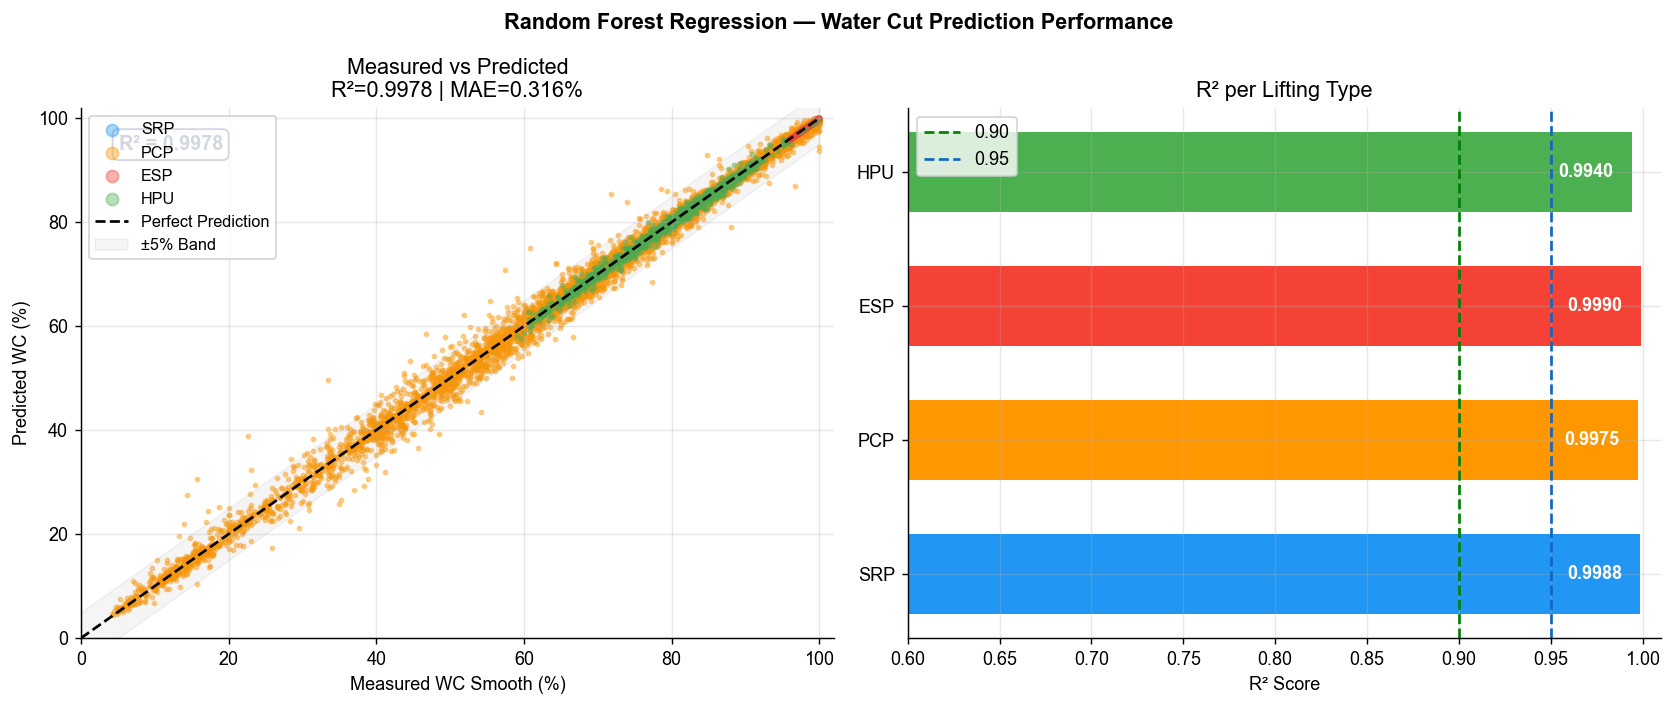

✓ Grafik 1 disimpan


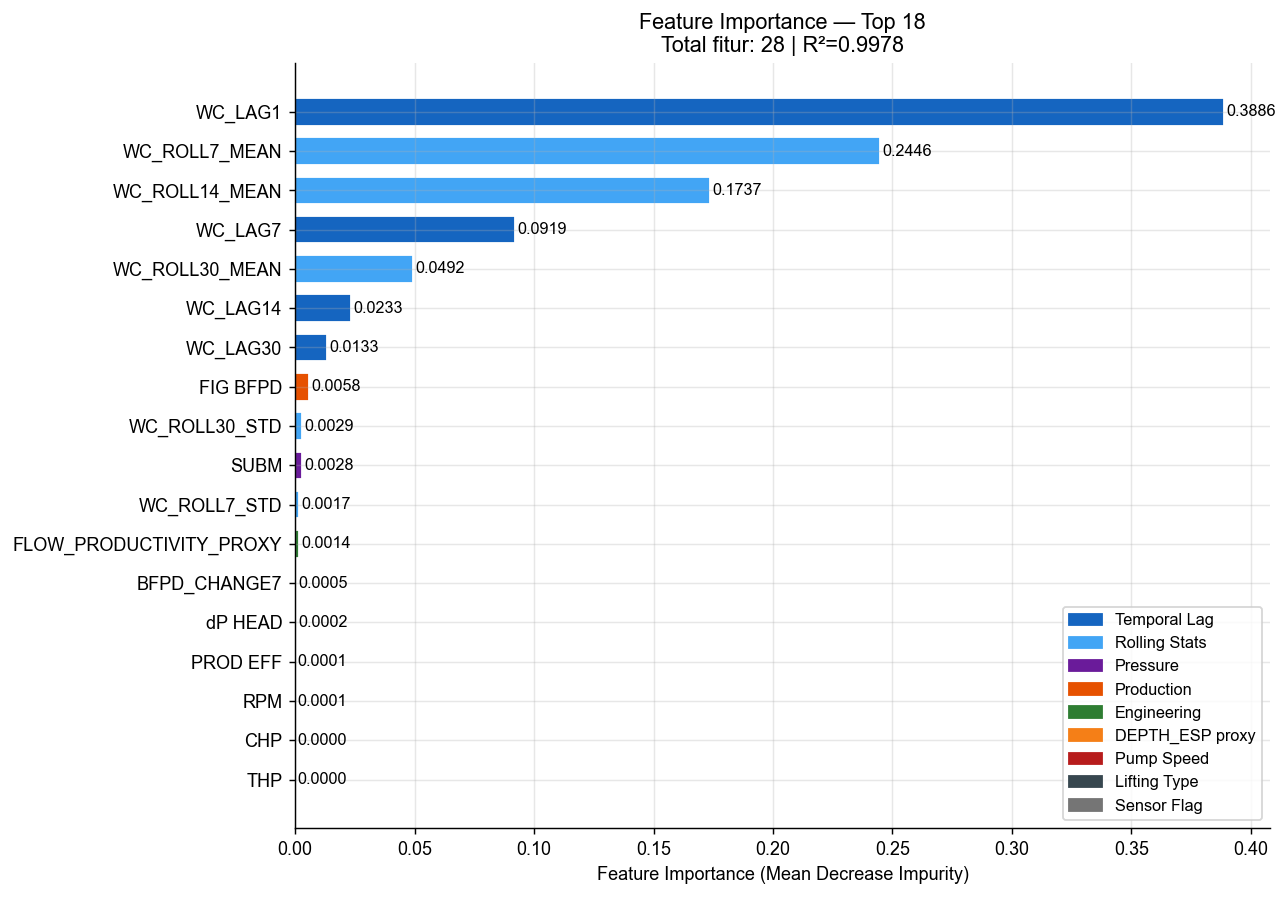

✓ Grafik 2 disimpan

Top 5 fitur:
  WC_LAG1                     : 0.3886 (38.9%)
  WC_ROLL7_MEAN               : 0.2446 (24.5%)
  WC_ROLL14_MEAN              : 0.1737 (17.4%)
  WC_LAG7                     : 0.0919 (9.2%)
  WC_ROLL30_MEAN              : 0.0492 (4.9%)


In [42]:
LIFT_COLORS = {'SRP':'#2196F3','PCP':'#FF9800','ESP':'#F44336','HPU':'#4CAF50','NF':'#9C27B0'}

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Random Forest Regression — Water Cut Prediction Performance',
             fontsize=12, fontweight='bold')

ax = axes[0]
for lt, color in LIFT_COLORS.items():
    m = df_res['LIFTING'] == lt
    if m.sum() < 5: continue
    ax.scatter(df_res.loc[m, TARGET], df_res.loc[m, 'WC_PRED'],
               c=color, s=5, alpha=0.4, label=lt, rasterized=True)
ax.plot([0,100],[0,100],'k--',linewidth=1.5,label='Perfect Prediction',zorder=5)
ax.fill_between([0,100],[5,105],[-5,95],alpha=0.08,color='gray',label='±5% Band')
ax.set_xlabel('Measured WC Smooth (%)'); ax.set_ylabel('Predicted WC (%)')
ax.set_xlim(0,102); ax.set_ylim(0,102)
ax.set_title(f'Measured vs Predicted\nR²={r2_test:.4f} | MAE={mae:.3f}%')
ax.legend(loc='upper left', markerscale=3, fontsize=9)
ax.text(0.05,0.92,f'R² = {r2_test:.4f}',transform=ax.transAxes,fontsize=11,
        fontweight='bold',color='#1F3864',
        bbox=dict(boxstyle='round,pad=0.3',facecolor='white',edgecolor='#1F3864'))

ax2 = axes[1]
r2_lt = {}
for lt in LIFT_COLORS:
    m = df_res['LIFTING']==lt
    if m.sum()>=20:
        r2_lt[lt] = r2_score(df_res.loc[m,TARGET], df_res.loc[m,'WC_PRED'])
bars = ax2.barh(list(r2_lt.keys()), list(r2_lt.values()),
                color=[LIFT_COLORS[l] for l in r2_lt], height=0.6)
for bar, val in zip(bars, r2_lt.values()):
    ax2.text(val-0.01, bar.get_y()+bar.get_height()/2,
             f'{val:.4f}', va='center', ha='right', fontweight='bold', color='white', fontsize=10)
ax2.axvline(0.90, color='green',  linestyle='--', linewidth=1.5, label='0.90')
ax2.axvline(0.95, color='#1565C0',linestyle='--', linewidth=1.5, label='0.95')
ax2.set_xlim(0.6, 1.01); ax2.set_xlabel('R² Score')
ax2.set_title('R² per Lifting Type'); ax2.legend()
plt.tight_layout()
plt.savefig(str(DIR_PLOTS/'Fig1_Actual_vs_Predicted.png'), dpi=200, bbox_inches='tight')
plt.show()
print(" Grafik 1 disimpan")

# ── Feature Importance ───────────────────────────────────────────────
fi = pd.DataFrame({'feature':FEATURES,'importance':model.feature_importances_}
                  ).sort_values('importance',ascending=False)
GROUP_COLORS = {
    'WC_LAG':'#1565C0','WC_ROLL':'#42A5F5','FIG BFPD':'#E65100','BFPD_CHANGE':'#E65100',
    'THP':'#6A1B9A','CHP':'#6A1B9A','SUBM':'#6A1B9A','dP HEAD':'#6A1B9A',
    'FLOW_PRODUCTIVITY_PROXY':'#2E7D32','PROD EFF':'#2E7D32',
    'LIFTING_CODE':'#37474F','SPM':'#B71C1C','RPM':'#B71C1C','HZ':'#B71C1C',
    'HAS_':'#757575','DEPTH_ESP':'#F57F17','PUMP_INTAKE':'#F57F17','DEPTH_SUBM':'#F57F17',
}
def get_color(f):
    for k,c in GROUP_COLORS.items():
        if k in f: return c
    return '#9E9E9E'

top = fi.head(18); colors = [get_color(f) for f in top['feature']]
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top['feature'], top['importance'], color=colors, edgecolor='white', height=0.7)
for bar, val in zip(bars, top['importance']):
    ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2, f'{val:.4f}', va='center', fontsize=9)
legend_items = [
    Patch(color='#1565C0',label='Temporal Lag'),Patch(color='#42A5F5',label='Rolling Stats'),
    Patch(color='#6A1B9A',label='Pressure'),Patch(color='#E65100',label='Production'),
    Patch(color='#2E7D32',label='Engineering'),Patch(color='#F57F17',label='DEPTH_ESP proxy'),
    Patch(color='#B71C1C',label='Pump Speed'),Patch(color='#37474F',label='Lifting Type'),
    Patch(color='#757575',label='Sensor Flag'),
]
ax.legend(handles=legend_items, fontsize=9, loc='lower right')
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title(f'Feature Importance — Top 18\nTotal fitur: {len(FEATURES)} | R²={r2_test:.4f}')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(str(DIR_PLOTS/'Fig2_Feature_Importance.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Grafik 2 disimpan")
print(f"\nTop 5 fitur:")
for _,r in fi.head(5).iterrows():
    print(f"  {r['feature']:<28}: {r['importance']:.4f} ({r['importance']*100:.1f}%)")

In [51]:
joblib.dump(model,    str(DIR_MODELS / 'Model Final.pkl'))
joblib.dump(rf_cs,    str(DIR_MODELS / 'rfr_watercut_coldstart.pkl'))
joblib.dump(FEATURES, str(DIR_MODELS / 'features_list.pkl'))
joblib.dump(FEAT_NL,  str(DIR_MODELS / 'Cold Start.pkl'))
joblib.dump(TARGET,   str(DIR_MODELS / 'target_col.pkl'))
print(f"\nModel disimpan ke: {DIR_MODELS.resolve()}")


Model disimpan ke: C:\Skripsi_WC\output\models


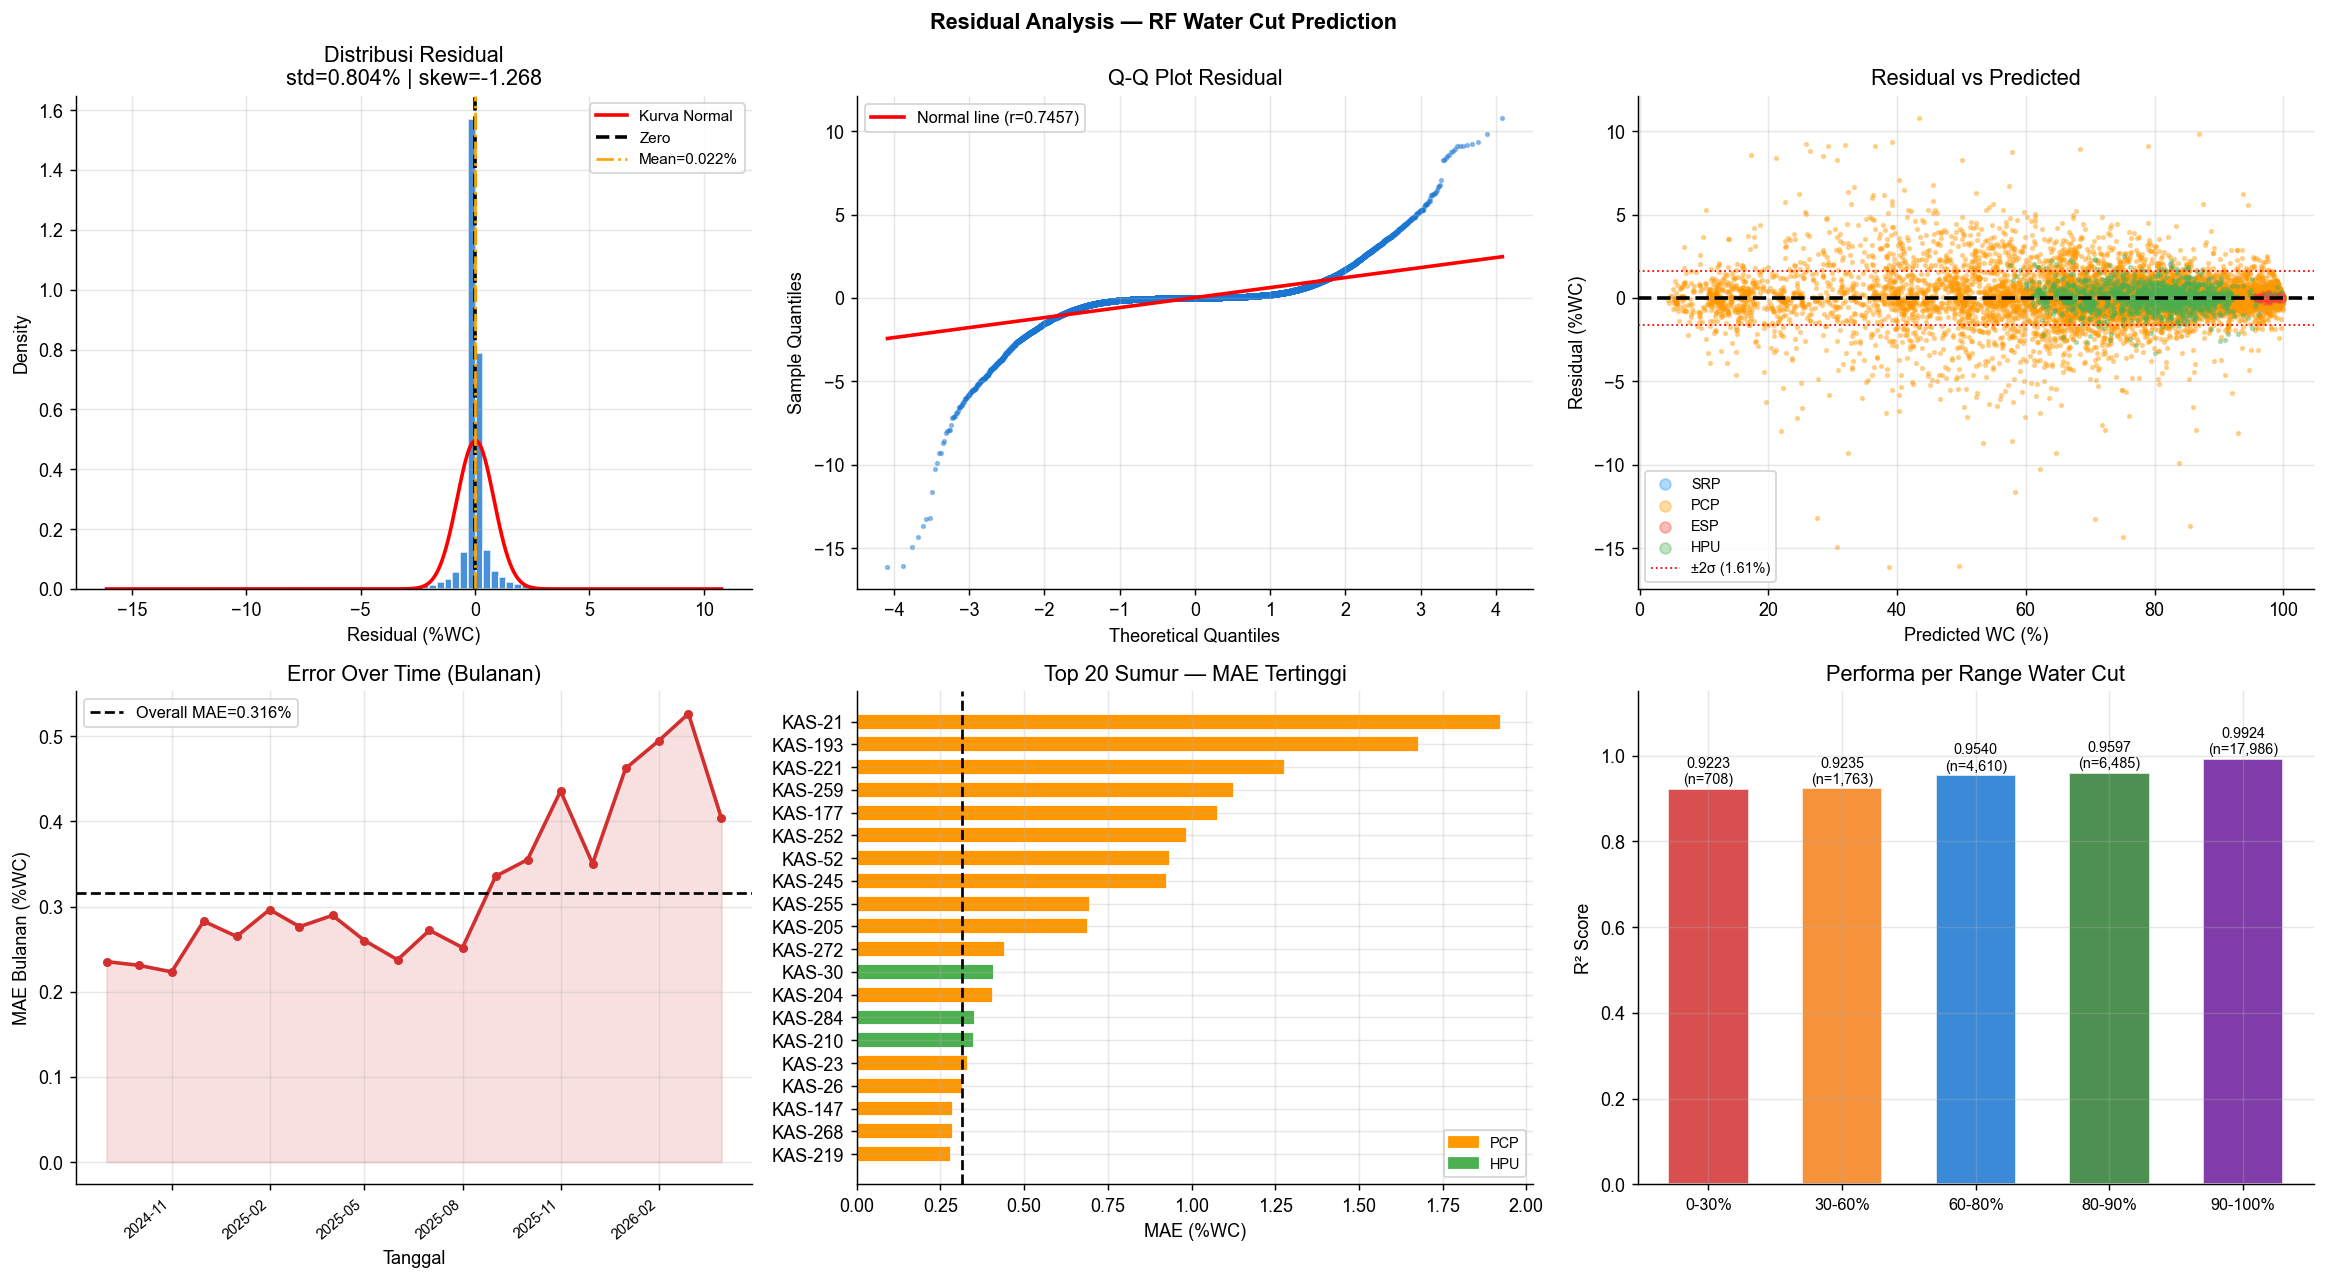

✓ Grafik 3 disimpan


In [44]:
residuals = np.array(y_test) - np.array(y_pred_test)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residual Analysis — RF Water Cut Prediction', fontsize=12, fontweight='bold')

ax = axes[0,0]
ax.hist(residuals, bins=80, color='#1976D2', edgecolor='white', alpha=0.8, density=True)
xr = np.linspace(residuals.min(), residuals.max(), 300)
ax.plot(xr, stats.norm.pdf(xr, residuals.mean(), residuals.std()), 'r-', lw=2, label='Kurva Normal')
ax.axvline(0, color='black', lw=2, ls='--', label='Zero')
ax.axvline(residuals.mean(), color='orange', lw=1.5, ls='-.', label=f'Mean={residuals.mean():.3f}%')
ax.set_xlabel('Residual (%WC)'); ax.set_ylabel('Density')
ax.set_title(f'Distribusi Residual\nstd={residuals.std():.3f}% | skew={stats.skew(residuals):.3f}')
ax.legend(fontsize=8.5); ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

ax2 = axes[0,1]
(osm, osr), (slope, intercept, r_corr) = stats.probplot(residuals, dist='norm')
ax2.scatter(osm, osr, color='#1976D2', s=4, alpha=0.4, rasterized=True)
ax2.plot([osm[0],osm[-1]],[slope*osm[0]+intercept,slope*osm[-1]+intercept],
         'r-', lw=2, label=f'Normal line (r={r_corr:.4f})')
ax2.set_xlabel('Theoretical Quantiles'); ax2.set_ylabel('Sample Quantiles')
ax2.set_title(f'Q-Q Plot Residual')
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)
ax2.spines['top'].set_visible(False); ax2.spines['right'].set_visible(False)

ax3 = axes[0,2]
for lt, color in LIFT_COLORS.items():
    m = df_res['LIFTING']==lt
    if m.sum() < 5: continue
    ax3.scatter(df_res.loc[m,'WC_PRED'], residuals[m.values],
                c=color, s=4, alpha=0.35, label=lt, rasterized=True)
ax3.axhline(0, color='black', lw=2, ls='--')
two_s = 2*residuals.std()
ax3.axhline(two_s,  color='red', lw=1, ls=':', label=f'±2σ ({two_s:.2f}%)')
ax3.axhline(-two_s, color='red', lw=1, ls=':')
ax3.set_xlabel('Predicted WC (%)'); ax3.set_ylabel('Residual (%WC)')
ax3.set_title('Residual vs Predicted')
ax3.legend(fontsize=8, markerscale=3); ax3.grid(alpha=0.3)
ax3.spines['top'].set_visible(False); ax3.spines['right'].set_visible(False)

ax4 = axes[1,0]
df_res_s = df_res.sort_values('DATE').copy()
df_res_s['abs_err'] = (df_res_s[TARGET] - df_res_s['WC_PRED']).abs()
df_res_s['month']   = df_res_s['DATE'].dt.to_period('M').dt.to_timestamp()
monthly_err = df_res_s.groupby('month')['abs_err'].mean()
ax4.plot(monthly_err.index, monthly_err.values, color='#D32F2F', lw=2, marker='o', markersize=4)
ax4.fill_between(monthly_err.index, monthly_err.values, alpha=0.15, color='#D32F2F')
ax4.axhline(mae, color='black', ls='--', lw=1.5, label=f'Overall MAE={mae:.3f}%')
ax4.set_xlabel('Tanggal'); ax4.set_ylabel('MAE Bulanan (%WC)')
ax4.set_title('Error Over Time (Bulanan)')
ax4.legend(fontsize=9); ax4.grid(alpha=0.3)
ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax4.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax4.xaxis.get_majorticklabels(), rotation=40, ha='right', fontsize=8)
ax4.spines['top'].set_visible(False); ax4.spines['right'].set_visible(False)

ax5 = axes[1,1]
wm_sorted = sorted(well_metrics.items(), key=lambda x: x[1]['MAE'], reverse=True)[:20]
wnames  = [w for w,_ in wm_sorted]; wmaes = [m['MAE'] for _,m in wm_sorted]
wcolors = [LIFT_COLORS.get(m['LIFTING'],'#888') for _,m in wm_sorted]
ax5.barh(wnames, wmaes, color=wcolors, height=0.7, edgecolor='white')
ax5.axvline(mae, color='black', ls='--', lw=1.5, label=f'Overall MAE={mae:.3f}%')
ax5.invert_yaxis(); ax5.set_xlabel('MAE (%WC)'); ax5.set_title('Top 20 Sumur — MAE Tertinggi')
legend_lt = [Patch(color=v,label=k) for k,v in LIFT_COLORS.items()
             if k in {m['LIFTING'] for _,m in wm_sorted}]
ax5.legend(handles=legend_lt, fontsize=8, loc='lower right'); ax5.grid(axis='x', alpha=0.3)
ax5.spines['top'].set_visible(False); ax5.spines['right'].set_visible(False)

ax6 = axes[1,2]
wc_ranges = ['0-30%','30-60%','60-80%','80-90%','90-100%']
r2_ranges, n_ranges = [], []
for rng in wc_ranges:
    grp = df_res[df_res['WC_RANGE']==rng]
    if len(grp)<10: r2_ranges.append(np.nan); n_ranges.append(0); continue
    r2_ranges.append(r2_score(grp[TARGET],grp['WC_PRED'])); n_ranges.append(len(grp))
clr_wc = ['#D32F2F','#F57F17','#1976D2','#2E7D32','#6A1B9A']
bars6  = ax6.bar(np.arange(len(wc_ranges)), r2_ranges, color=clr_wc, width=0.6, edgecolor='white', alpha=0.85)
for bar, val, n in zip(bars6, r2_ranges, n_ranges):
    if not np.isnan(val):
        ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                 f'{val:.4f}\n(n={n:,})', ha='center', va='bottom', fontsize=8)
ax6.set_xticks(np.arange(len(wc_ranges))); ax6.set_xticklabels(wc_ranges, fontsize=9)
ax6.set_ylabel('R² Score'); ax6.set_ylim(0,1.15); ax6.set_title('Performa per Range Water Cut')
ax6.grid(axis='y', alpha=0.3)
ax6.spines['top'].set_visible(False); ax6.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(str(DIR_PLOTS/'Fig3_Residual.png'), dpi=200, bbox_inches='tight')
plt.show()
print("✓ Grafik 3 disimpan")

In [45]:
X_full      = df_s[FEATURES].fillna(0)
y_full_pred = model.predict(X_full)

df_full = df_s.copy()
df_full['WC_PRED'] = y_full_pred
df_full['SPLIT']   = np.where(df_full['DATE'] < cut_date, 'Train', 'Test')
df_full['RESIDUAL']= df_full[TARGET] - df_full['WC_PRED']

print(f"Prediksi full dataset selesai!")
print(f"  Total baris : {len(df_full):,}")
print(f"  Total sumur : {df_full['WELL'].nunique()}")
print(f"  Train       : {(df_full['SPLIT']=='Train').sum():,} baris")
print(f"  Test        : {(df_full['SPLIT']=='Test').sum():,} baris")
print()

# Verifikasi per lifting
for lt in ['ESP','SRP','PCP','HPU']:
    g = df_full[df_full['LIFTING']==lt]
    print(f"  {lt}: {g['WELL'].nunique():>3} sumur | {len(g):>7,} baris")

Prediksi full dataset selesai!
  Total baris : 157,507
  Total sumur : 79
  Train       : 125,955 baris
  Test        : 31,552 baris

  ESP:  13 sumur |  14,997 baris
  SRP:  11 sumur |  19,228 baris
  PCP:  55 sumur | 114,231 baris
  HPU:   7 sumur |   9,051 baris


In [46]:
LIFT_ORDER_PLOT = ['ESP', 'SRP', 'HPU', 'PCP']
LIFT_COLORS_PLOT = {'SRP':'#2196F3','PCP':'#FF9800','ESP':'#F44336',
                    'HPU':'#4CAF50','NF':'#9C27B0'}

well_plot_data = {}
for w, grp in df_full.groupby('WELL'):
    grp_s = grp.sort_values('DATE').reset_index(drop=True)
    if len(grp_s) < 5: continue
    # Metrik dihitung hanya pada periode test
    grp_test = grp_s[grp_s['SPLIT'] == 'Test']
    if len(grp_test) >= 10 and grp_test[TARGET].var() >= 0.01:
        r2w  = __import__('sklearn.metrics',fromlist=['r2_score']).r2_score(
                   grp_test[TARGET], grp_test['WC_PRED'])
        maew = __import__('sklearn.metrics',fromlist=['mean_absolute_error']).mean_absolute_error(
                   grp_test[TARGET], grp_test['WC_PRED'])
        n_test = len(grp_test)
    else:
        r2w = np.nan; maew = np.nan; n_test = len(grp_test)
    well_plot_data[w] = {
        'data': grp_s, 'R2': r2w, 'MAE': maew,
        'n_total': len(grp_s), 'n_test': n_test,
        'LIFTING': grp_s['LIFTING'].iloc[0],
    }

wells_sorted = sorted(
    well_plot_data.keys(),
    key=lambda w: (
        LIFT_ORDER_PLOT.index(well_plot_data[w]['LIFTING'])
        if well_plot_data[w]['LIFTING'] in LIFT_ORDER_PLOT else 99, w
    ))

print(f"Total sumur diplot: {len(wells_sorted)}")
for lt in LIFT_ORDER_PLOT:
    n_lt = sum(1 for w in wells_sorted if well_plot_data[w]['LIFTING']==lt)
    print(f"  {lt}: {n_lt} sumur")

N_COLS = 2; N_PER_PAGE = 6
pages = [wells_sorted[i:i+N_PER_PAGE] for i in range(0, len(wells_sorted), N_PER_PAGE)]
total_pages = len(pages)
print(f"  Total halaman: {total_pages}")

for pi, page_wells in enumerate(pages, 1):
    n_rows = math.ceil(len(page_wells) / N_COLS)
    fig_w, axes_w = plt.subplots(n_rows, N_COLS, figsize=(16, 4.8*n_rows))
    if n_rows == 1: axes_w = axes_w.reshape(1, -1)
    elif N_COLS == 1: axes_w = axes_w.reshape(-1, 1)

    fig_w.suptitle(
        f'Water Cut — Actual vs Predicted per Sumur (Halaman {pi}/{total_pages})\n'
        f'Training: sebelum {cut_date.date()}  |  Test: sesudah {cut_date.date()}  |  '
        f'Model: Random Forest Regression',
        fontsize=11, fontweight='bold', y=0.99)

    for i, well in enumerate(page_wells):
        row, col = divmod(i, N_COLS)
        ax   = axes_w[row, col]
        info = well_plot_data[well]
        grp_s = info['data']
        lt    = info['LIFTING']
        color = LIFT_COLORS_PLOT.get(lt, '#333333')

        # Split train/test
        tr = grp_s[grp_s['SPLIT']=='Train']
        te = grp_s[grp_s['SPLIT']=='Test']

        # Raw scatter
        ax.scatter(grp_s['DATE'], grp_s['FIG %WC'],
                   color='#CFD8DC', s=6, alpha=0.4, zorder=1, label='Raw WC')
        # Actual smooth
        ax.plot(grp_s['DATE'], grp_s[TARGET],
                color='#212121', lw=1.6, alpha=0.9, zorder=3, label='Actual (Smooth)')
        # Predicted — train (abu tipis)
        if len(tr):
            ax.plot(tr['DATE'], tr['WC_PRED'],
                    color=color, lw=1.2, ls='--', alpha=0.4, zorder=4)
        # Predicted — test (warna penuh)
        if len(te):
            ax.plot(te['DATE'], te['WC_PRED'],
                    color=color, lw=2.0, ls='--', alpha=0.95, zorder=5,
                    label=f'Predicted-Test ({lt})')
        # Garis vertikal cutoff
        ax.axvline(cut_date, color='red', lw=1.2, ls=':', alpha=0.7, label='Cutoff')
        # Error shading (test only)
        if len(te):
            ax.fill_between(te['DATE'], te[TARGET], te['WC_PRED'],
                            alpha=0.10, color=color, zorder=2)

        r2_str  = f'R²={info["R2"]:.4f}' if pd.notna(info['R2']) else 'R²=N/A'
        mae_str = f'MAE={info["MAE"]:.3f}%' if pd.notna(info['MAE']) else 'MAE=N/A'
        ax.set_title(f'{well} ({lt})  |  {r2_str}  |  {mae_str}  '
                     f'|  n_total={info["n_total"]}  n_test={info["n_test"]}',
                     fontsize=8.5, fontweight='bold')
        ax.set_xlabel('Tanggal', fontsize=8)
        ax.set_ylabel('Water Cut (%)', fontsize=8)

        y_all = pd.concat([grp_s['FIG %WC'], grp_s[TARGET], grp_s['WC_PRED']]).dropna()
        ax.set_ylim(max(0, y_all.min()-5), min(100, y_all.max()+5))
        ax.set_xlim(grp_s['DATE'].min()-pd.Timedelta(days=14),
                    grp_s['DATE'].max()+pd.Timedelta(days=14))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=7.5)
        ax.grid(True, alpha=0.22, linestyle='--')
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        ax.legend(fontsize=7, loc='best', ncol=2, framealpha=0.85, handlelength=1.2)

    for i in range(len(page_wells), n_rows*N_COLS):
        row, col = divmod(i, N_COLS); axes_w[row, col].set_visible(False)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    fname = DIR_PLOTS / f'Fig4_PerWell_AllWells_Page{pi:02d}.png'
    plt.savefig(str(fname), dpi=180, bbox_inches='tight', facecolor='white')
    plt.close()
    print(f'  ✓ Hal {pi:>2}/{total_pages} — {fname.name}')

print(f'\n✓ Semua {len(wells_sorted)} sumur selesai diplot!')

Total sumur diplot: 79
  ESP: 12 sumur
  SRP: 6 sumur
  HPU: 6 sumur
  PCP: 55 sumur
  Total halaman: 14
  ✓ Hal  1/14 — Fig4_PerWell_AllWells_Page01.png
  ✓ Hal  2/14 — Fig4_PerWell_AllWells_Page02.png
  ✓ Hal  3/14 — Fig4_PerWell_AllWells_Page03.png
  ✓ Hal  4/14 — Fig4_PerWell_AllWells_Page04.png
  ✓ Hal  5/14 — Fig4_PerWell_AllWells_Page05.png
  ✓ Hal  6/14 — Fig4_PerWell_AllWells_Page06.png
  ✓ Hal  7/14 — Fig4_PerWell_AllWells_Page07.png
  ✓ Hal  8/14 — Fig4_PerWell_AllWells_Page08.png
  ✓ Hal  9/14 — Fig4_PerWell_AllWells_Page09.png
  ✓ Hal 10/14 — Fig4_PerWell_AllWells_Page10.png
  ✓ Hal 11/14 — Fig4_PerWell_AllWells_Page11.png
  ✓ Hal 12/14 — Fig4_PerWell_AllWells_Page12.png
  ✓ Hal 13/14 — Fig4_PerWell_AllWells_Page13.png
  ✓ Hal 14/14 — Fig4_PerWell_AllWells_Page14.png

✓ Semua 79 sumur selesai diplot!


In [52]:
# ── Export

export_cols = ['DATE', 'WELL', 'LIFTING', 'SPLIT',
               'FIG BFPD', 'THP', 'CHP', 'dP HEAD',
               TARGET, 'WC_PRED', 'RESIDUAL', 'FIG %WC']
export_cols = [c for c in export_cols if c in df_full.columns]

df_export = df_full[export_cols].copy()
df_export = df_export.sort_values(['WELL', 'DATE']).reset_index(drop=True)
df_export['DATE'] = df_export['DATE'].dt.date   # simpan sebagai date bukan datetime

# Hitung metrik per sumur untuk sheet ringkasan
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

summary_rows = []
for w, grp in df_export.groupby('WELL'):
    grp_test = grp[grp['SPLIT']=='Test'].dropna(subset=[TARGET,'WC_PRED'])
    grp_all  = grp.dropna(subset=[TARGET,'WC_PRED'])
    lt       = grp['LIFTING'].iloc[0]

    def safe_r2(y, yp):
        return r2_score(y, yp) if len(y)>=2 and y.var()>=0.01 else np.nan

    summary_rows.append({
        'WELL':       w,
        'LIFTING':    lt,
        'N_TOTAL':    len(grp_all),
        'N_TEST':     len(grp_test),
        'WC_MEAN_%':  round(grp_all[TARGET].mean(), 2),
        'R2_TEST':    round(safe_r2(grp_test[TARGET], grp_test['WC_PRED']), 4)
                      if len(grp_test)>=10 else np.nan,
        'RMSE_TEST':  round(np.sqrt(mean_squared_error(grp_test[TARGET], grp_test['WC_PRED'])), 3)
                      if len(grp_test)>=10 else np.nan,
        'MAE_TEST':   round(mean_absolute_error(grp_test[TARGET], grp_test['WC_PRED']), 3)
                      if len(grp_test)>=10 else np.nan,
    })

df_summary = pd.DataFrame(summary_rows).sort_values(['LIFTING','WELL']).reset_index(drop=True)

# Tulis ke Excel dengan dua sheet
excel_path = DIR_MODELS / 'WC_Prediction_Results.xlsx'
with pd.ExcelWriter(str(excel_path), engine='openpyxl') as writer:

    # Sheet 1: Ringkasan per sumur
    df_summary.to_excel(writer, sheet_name='Ringkasan_per_Sumur', index=False)

    # Sheet 2-5: Data detail per lifting type
    for lt in ['ESP','SRP','PCP','HPU']:
        df_lt = df_export[df_export['LIFTING']==lt]
        if len(df_lt) == 0: continue
        df_lt.to_excel(writer, sheet_name=f'Detail_{lt}', index=False)

    # Sheet 6: Hanya test set (untuk laporan)
    df_test_only = df_export[df_export['SPLIT']=='Test']
    df_test_only.to_excel(writer, sheet_name='TestSet_Only', index=False)

print(f"✓ Excel tersimpan: {excel_path}")
print(f"  Sheet 'Ringkasan_per_Sumur' : {len(df_summary)} sumur")
for lt in ['ESP','SRP','PCP','HPU']:
    n = len(df_export[df_export['LIFTING']==lt])
    if n: print(f"  Sheet 'Detail_{lt}'          : {n:,} baris")
print(f"  Sheet 'TestSet_Only'        : {len(df_test_only):,} baris")
print()

✓ Excel tersimpan: C:\Skripsi_WC\output\models\WC_Prediction_Results.xlsx
  Sheet 'Ringkasan_per_Sumur' : 79 sumur
  Sheet 'Detail_ESP'          : 14,997 baris
  Sheet 'Detail_SRP'          : 19,228 baris
  Sheet 'Detail_PCP'          : 114,231 baris
  Sheet 'Detail_HPU'          : 9,051 baris
  Sheet 'TestSet_Only'        : 31,552 baris

